In [1]:
here::i_am("atac/chrombpnet/plot_contributions.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code



In [38]:
library(ggseqlogo)
library(rhdf5)

args = list()
args$celltypes = c('PS_EOi') #, 'PS_EOd'

In [126]:
peaks = fread('/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/all_peaks.bed')[, I := .I] %>% 
    .[, peak := paste0(V1, ":", V2+1, '-', V3)]

In [6]:
library(reticulate)
np <- import("numpy")

In [175]:
contributions <- np$load("/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/PS_EOi/predictions/contributions.npz")
contributions = array(contributions$f["arr_0"], dim = c(206925, 4, 1000))

sequences <- np$load("/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/PS_EOi/predictions/sequences.npz")
sequences = array(sequences$f["arr_0"], dim = c(206925, 4, 1000))

PS_EOi = contributions * sequences

contributions <- np$load("/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/PS_EOd/predictions/contributions.npz")
contributions = array(contributions$f["arr_0"], dim = c(206925, 4, 1000))

sequences <- np$load("/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/PS_EOd/predictions/sequences.npz")
sequences = array(sequences$f["arr_0"], dim = c(206925, 4, 1000))

PS_EOd = contributions * sequences

In [184]:
min(tmp)

[1] -0.004646301

[1] 0.02798462

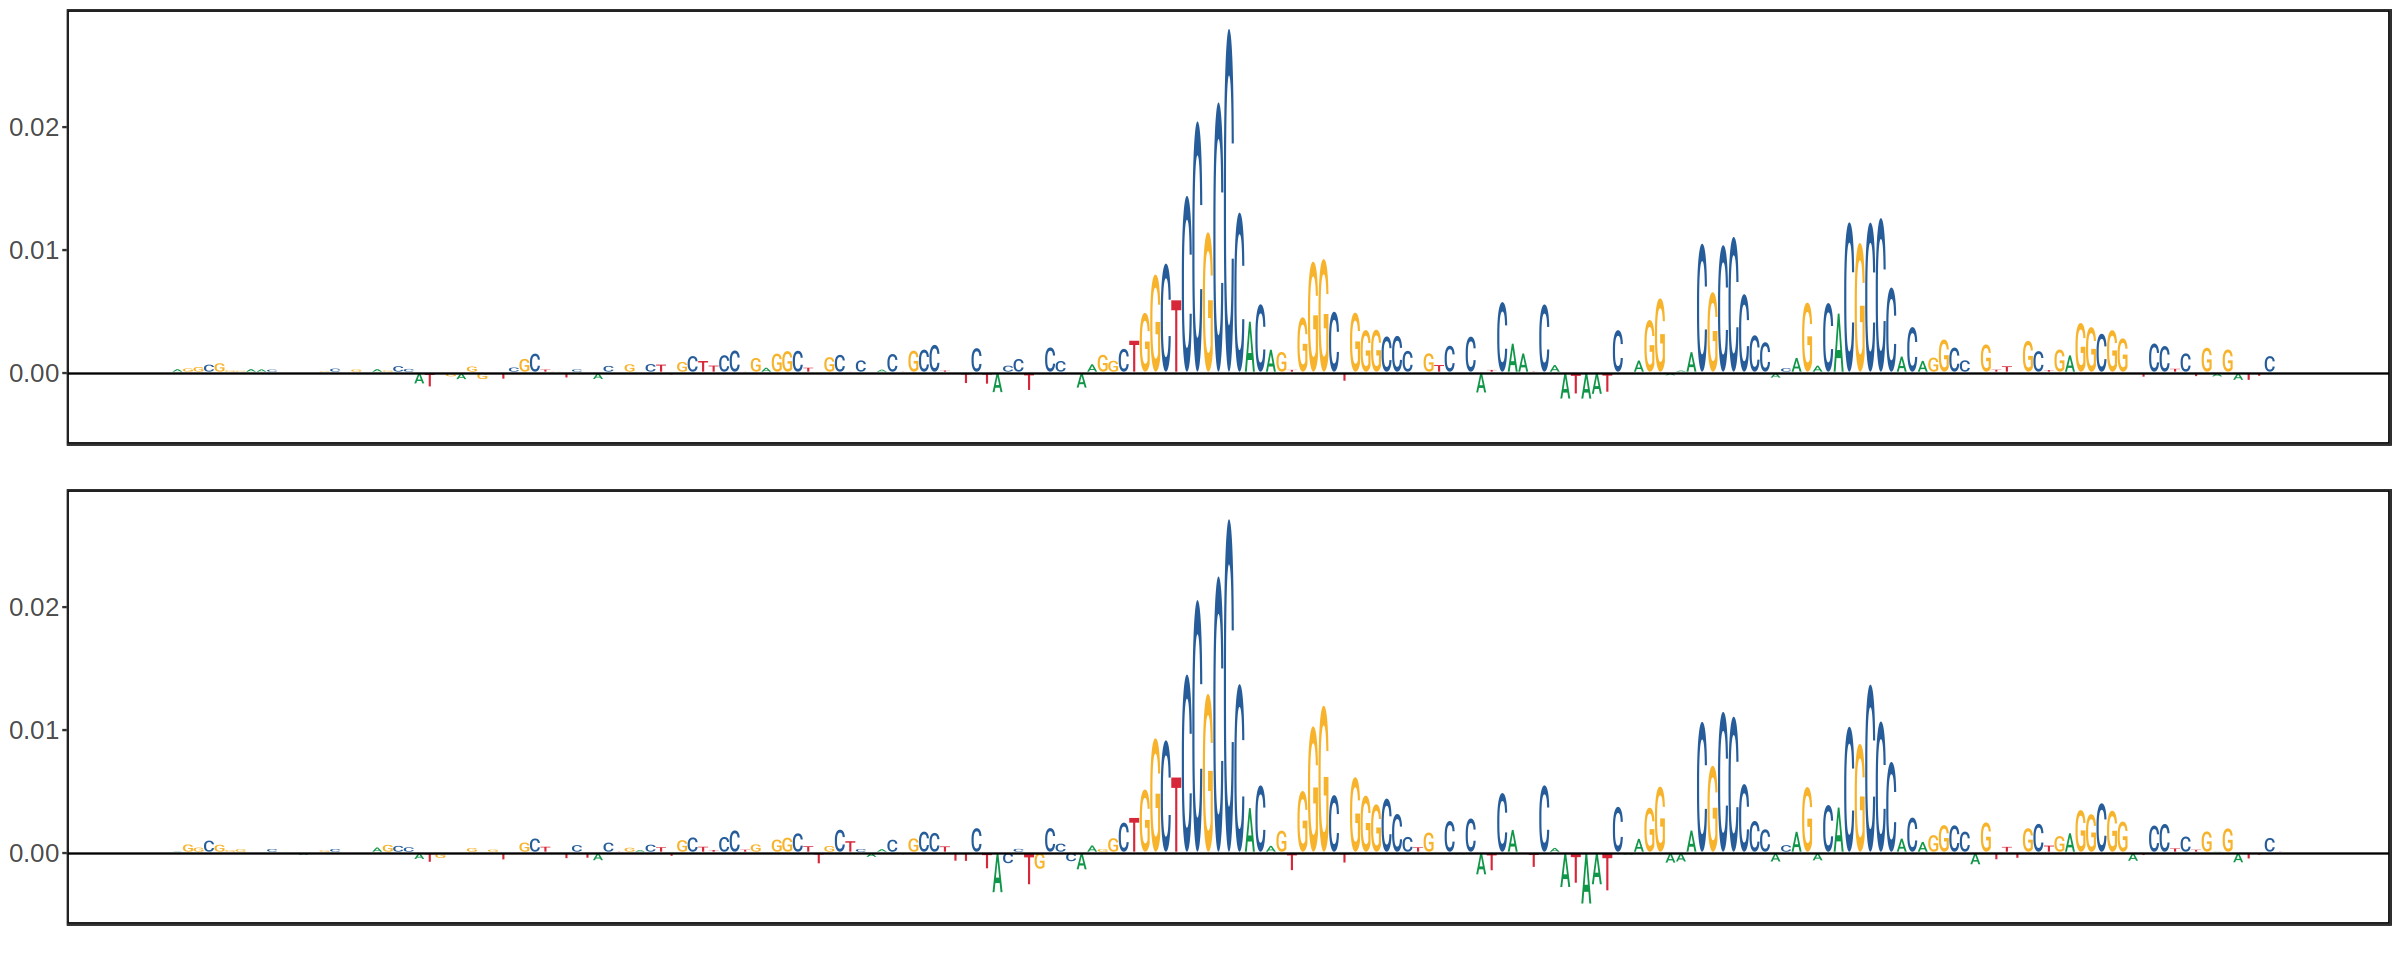

In [233]:
peak = peaks[peak == 'chr9:118704796-118706909', I]
options(repr.plot.width = 20, repr.plot.height = 8)
start = 400
end = 600

# start = 0
# end = 1000

max(c(PS_EOi[peak,,], PS_EOd[peak,,]))
tmp1 = PS_EOi[peak,,start:end]
rownames(tmp1) = c('A', 'C', 'G', 'T')

tmp2 = PS_EOd[peak,,start:end]
rownames(tmp2) = c('A', 'C', 'G', 'T')

p1 = ggseqlogo(tmp1, method='custom', seq_type='dna') + ylab('my custom height') + 
            geom_hline(yintercept = 0) +
                theme_bw() + 
                ylim(min(c(tmp1, tmp2)), max(c(tmp1, tmp2))) + 
                theme(panel.grid = element_blank(), 
                      panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                      axis.text.y = element_text(size = 15),
                     axis.title.y = element_blank(),
                     axis.text.x = element_blank(),
                     axis.ticks.x = element_blank())



p2 = ggseqlogo(tmp2, method='custom', seq_type='dna') + ylab('my custom height') + 
            geom_hline(yintercept = 0) +
                theme_bw() + 
                ylim(min(c(tmp1, tmp2)), max(c(tmp1, tmp2))) + 
                theme(panel.grid = element_blank(), 
                      panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                      axis.text.y = element_text(size = 15),
                     axis.title.y = element_blank(),
                     axis.text.x = element_blank(),
                     axis.ticks.x = element_blank())

ggarrange(p1, p2, ncol = 1, align = 'hv')

# Differential peaks

In [366]:
plot_peak = function(input_peak, start, end){
    peak = peaks[peak == input_peak, I]
    tmp1 = PS_EOi[peak,,start:end]
    rownames(tmp1) = c('A', 'C', 'G', 'T')

    tmp2 = PS_EOd[peak,,start:end]
    rownames(tmp2) = c('A', 'C', 'G', 'T')

    p1 = suppressMessages(ggseqlogo(tmp1, method='custom', seq_type='dna') + ylab('my custom height') + 
                geom_hline(yintercept = 0) +
                    theme_bw() + 
                    ylim(min(c(tmp1, tmp2)), max(c(tmp1, tmp2))) + 
                        scale_x_continuous(expand = c(0,0)) + 
                    theme(panel.grid = element_blank(), 
                          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                          axis.text.y = element_text(size = 15),
                         axis.title.y = element_blank(),
                         axis.text.x = element_blank(),
                         axis.ticks.x = element_blank()))



    p2 = suppressMessages(ggseqlogo(tmp2, method='custom', seq_type='dna') + ylab('my custom height') + 
                geom_hline(yintercept = 0) +
                    theme_bw() + 
                    ylim(min(c(tmp1, tmp2)), max(c(tmp1, tmp2))) + 
                    scale_x_continuous(expand = c(0,0)) + 
                    theme(panel.grid = element_blank(), 
                          panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                          axis.text.y = element_text(size = 15),
                         axis.title.y = element_blank(),
                         axis.text.x = element_blank(),
                         axis.ticks.x = element_blank()))

    plot = ggarrange(suppressMessages({p1}), p2, ncol = 1, align = 'hv')
    annotate_figure(plot, top = text_grob(input_peak, 
               color = "black", face = "bold", size = 21))
}

In [367]:
# Eomes KD vs WT
DARs = fread(sprintf('%s/results/rna_atac/differential/v2/expression/celltype_DARs_nPS_nPS_KD_WT_edgeR.txt.gz', io$basedir))

In [368]:
# Eomes dependent vs independent WT
DARs = fread(sprintf('%s/results/rna_atac/differential/v2/expression/celltype_DARs_EOdPS_nPS_WTonly_edgeR.txt.gz', io$basedir))

In [369]:
DARs = DARs %>% 
    .[,`:=`(chr = str_split(gene, ":") %>% map_chr(1),
            start = str_split(gene, ":") %>% map_chr(2) %>% str_split(., "-") %>% map_chr(1) %>% as.numeric(),
            end = str_split(gene, ":") %>% map_chr(2) %>% str_split(., "-") %>% map_chr(2) %>% as.numeric())] %>% 
    .[, centre := start + (end-start)/2] %>%
    .[, peak := paste0(chr, ':', centre - 1056, '-', centre + 1057)] %>% 
    .[order(padj_fdr)]

Warning message in mclapply(1:40, function(x) {:
“scheduled cores 22, 3 encountered errors in user code, all values of the jobs will be affected”


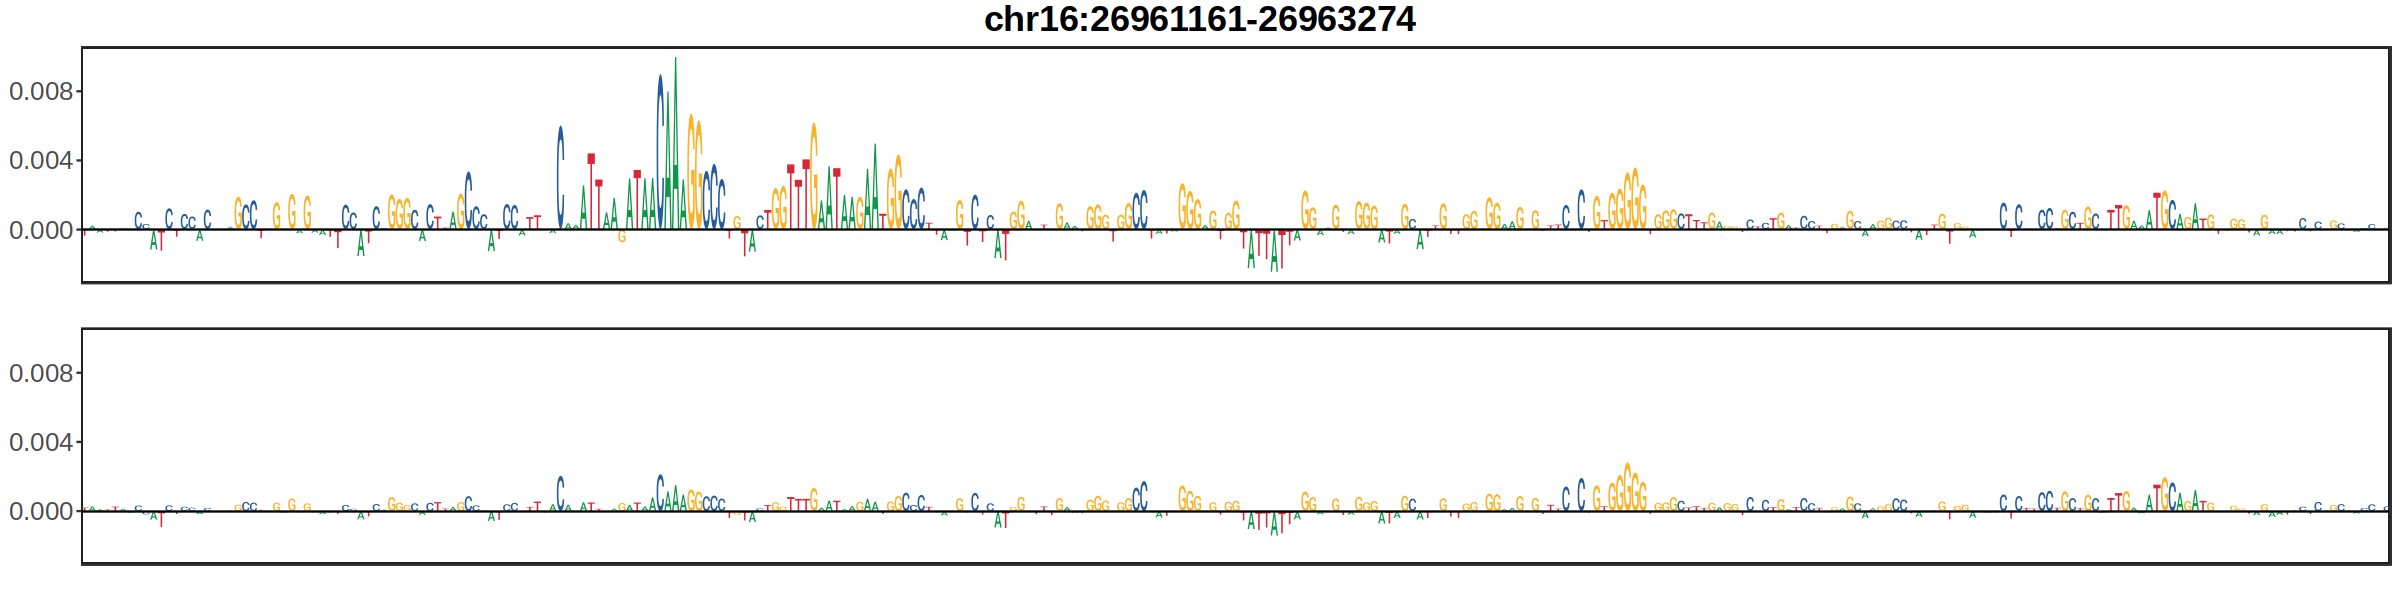

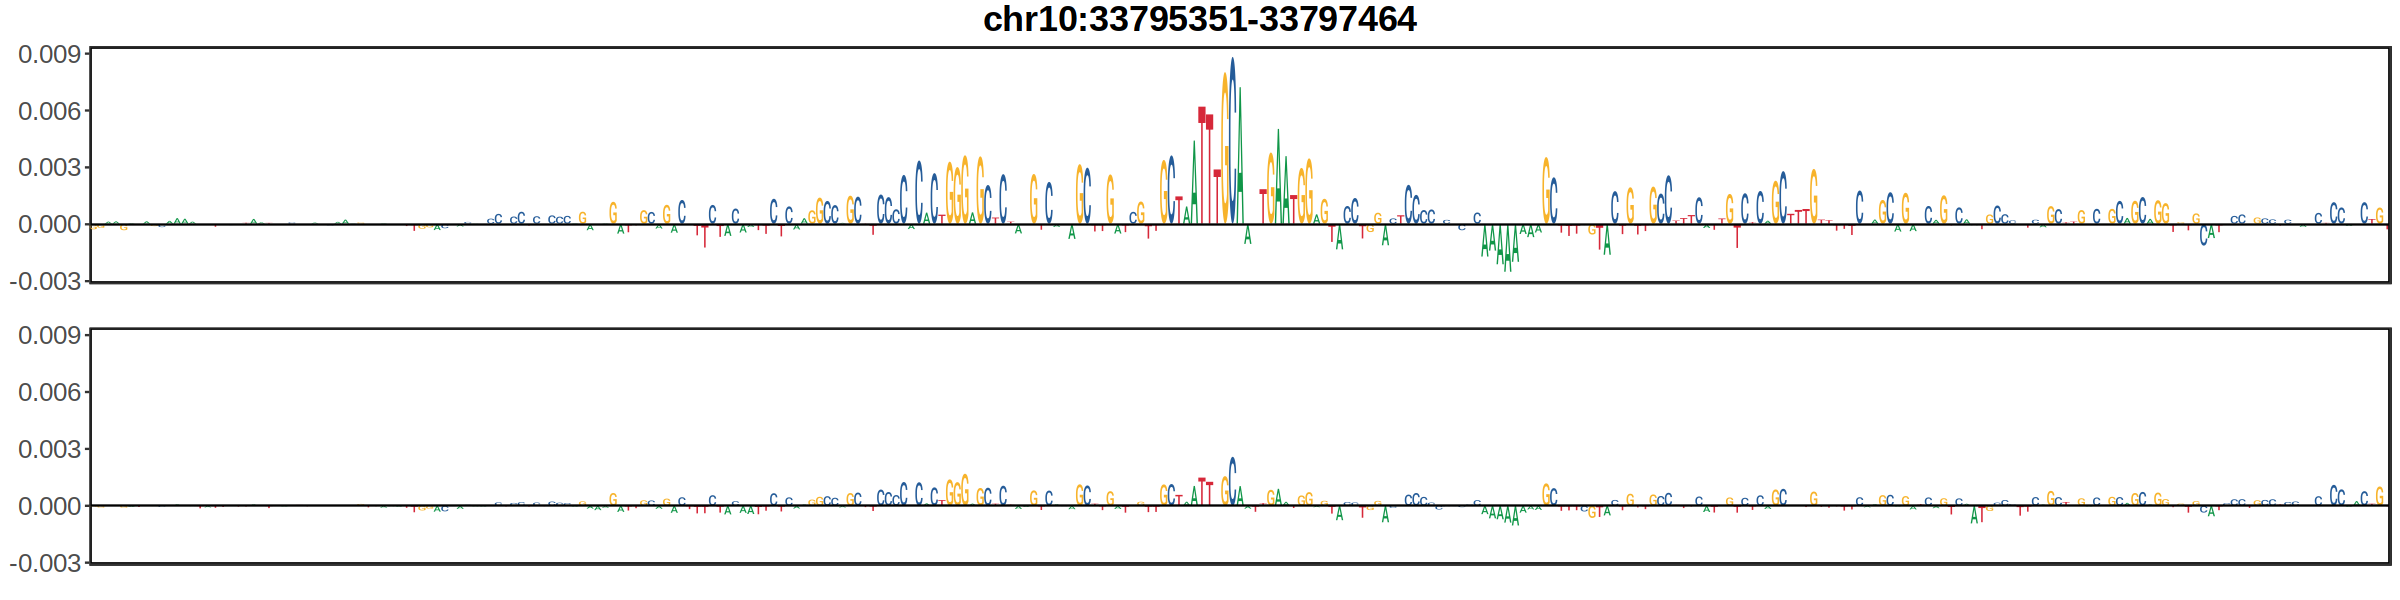

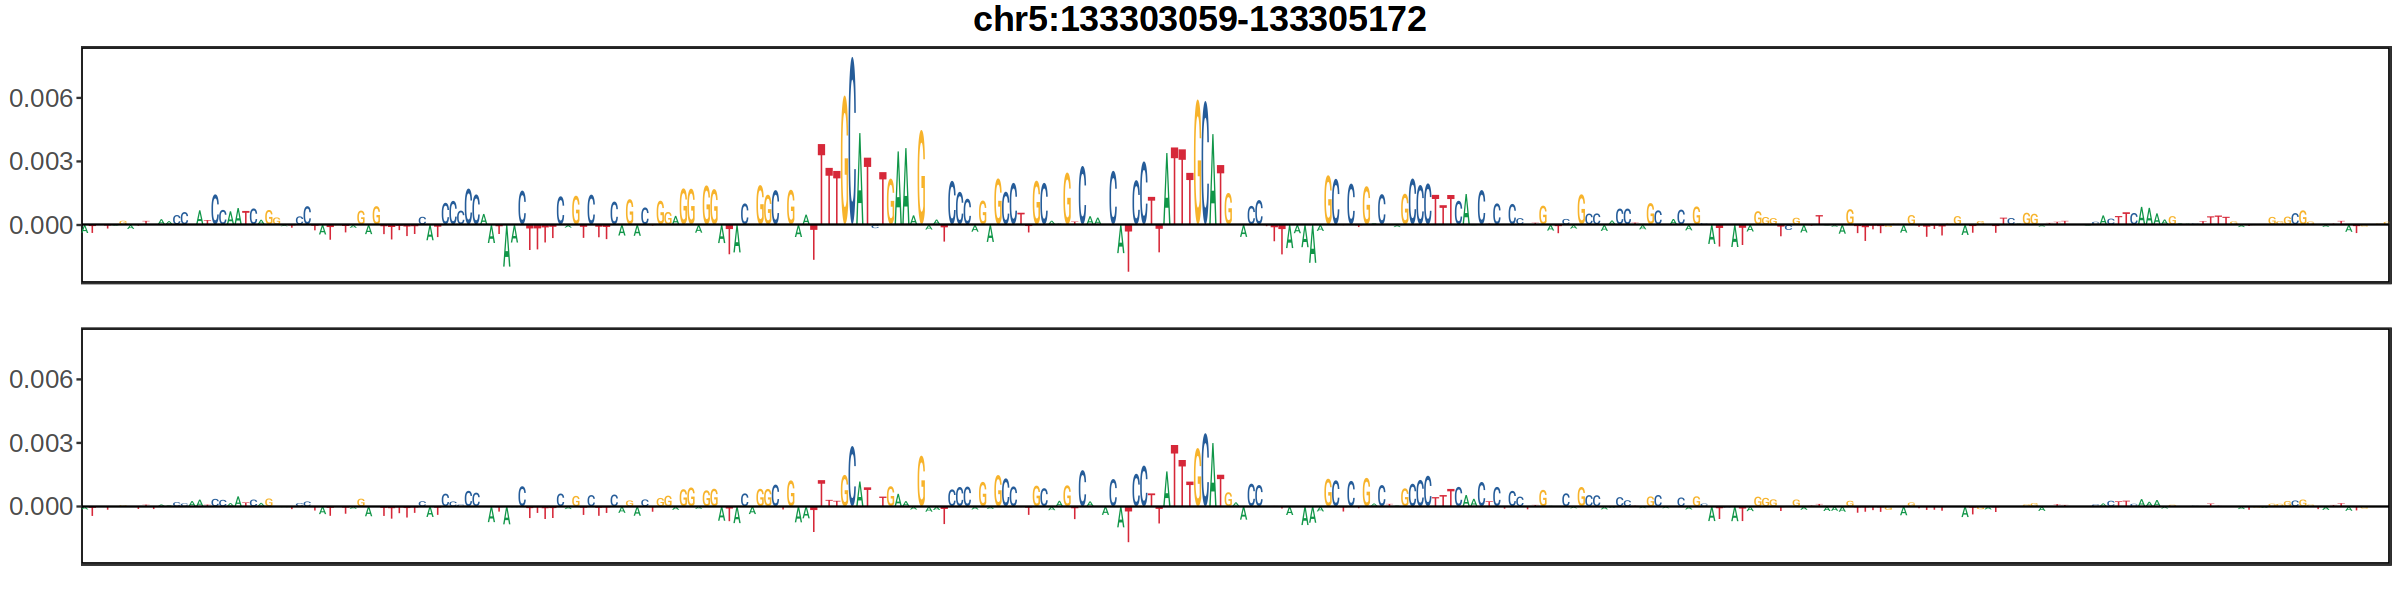

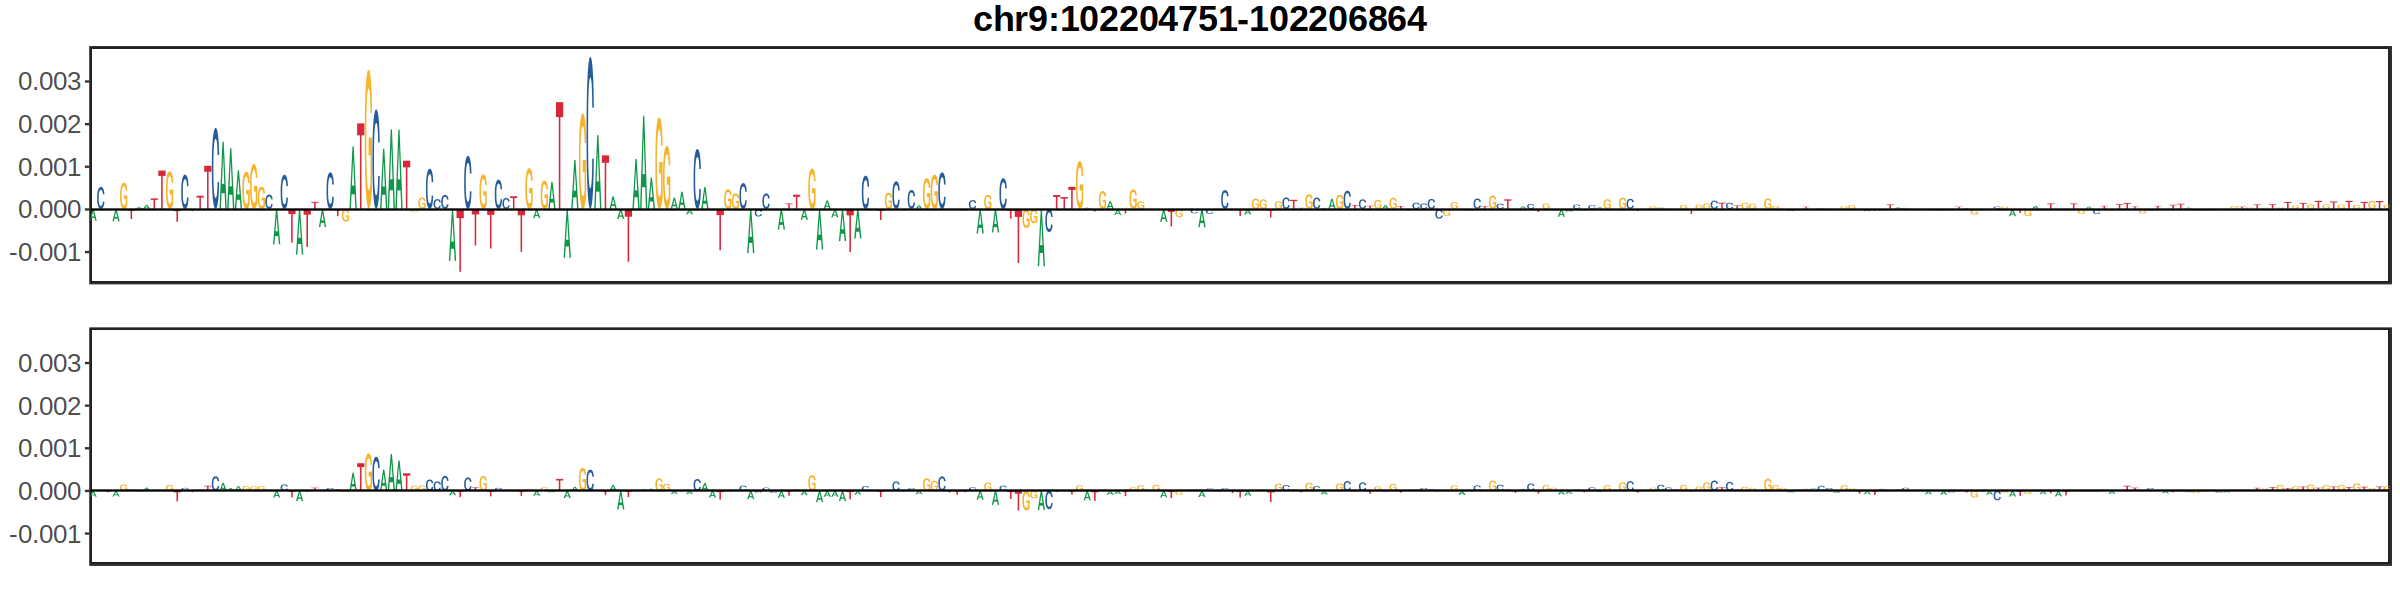

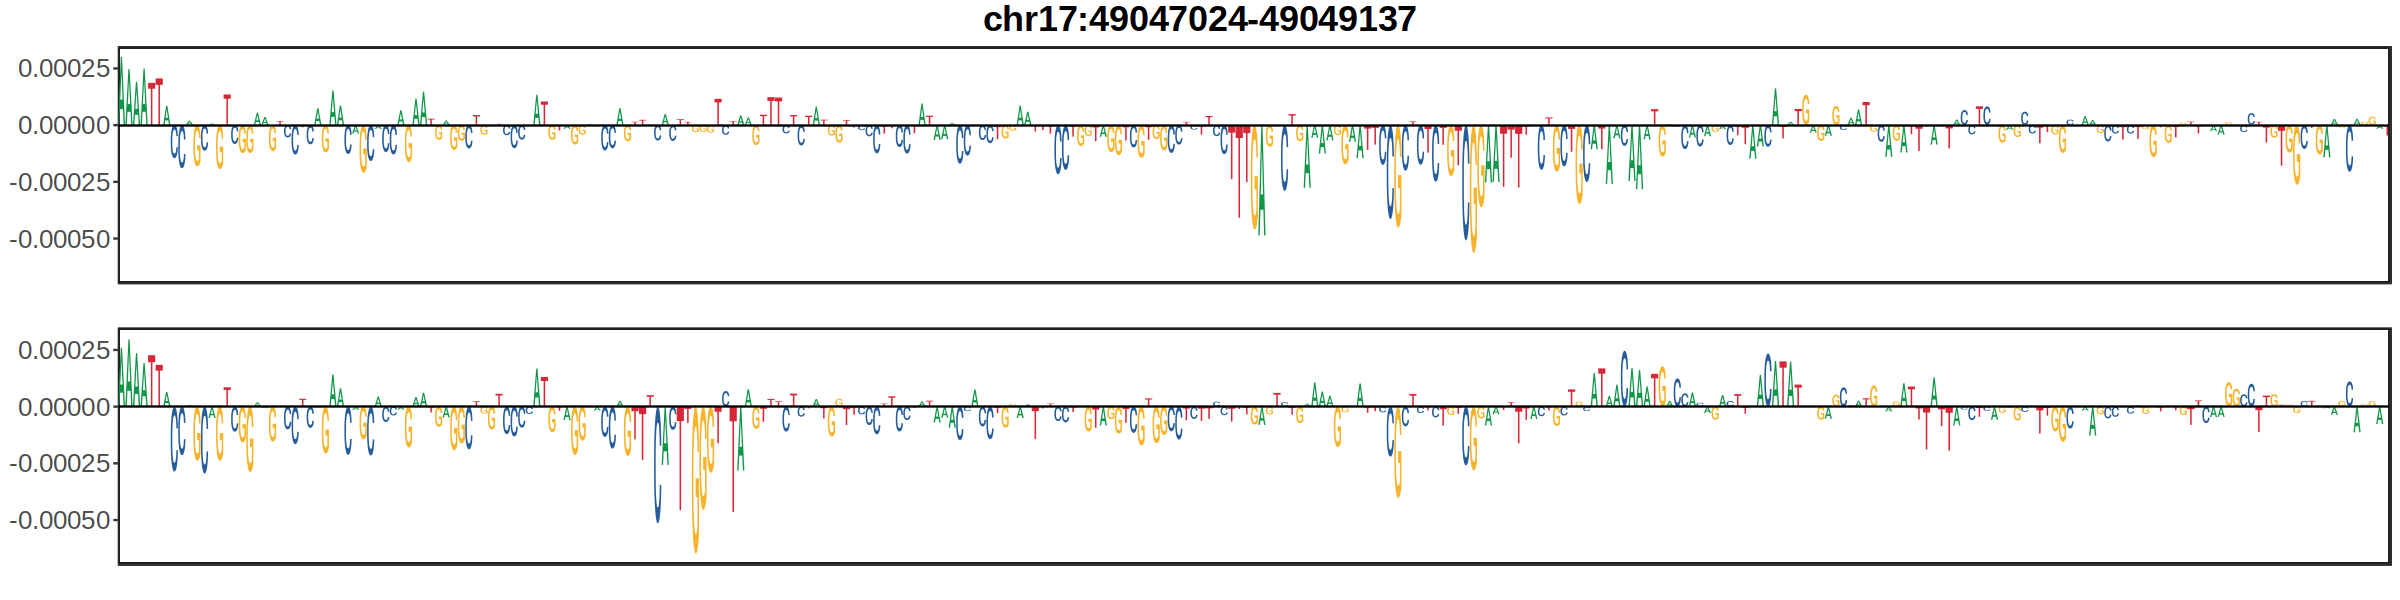

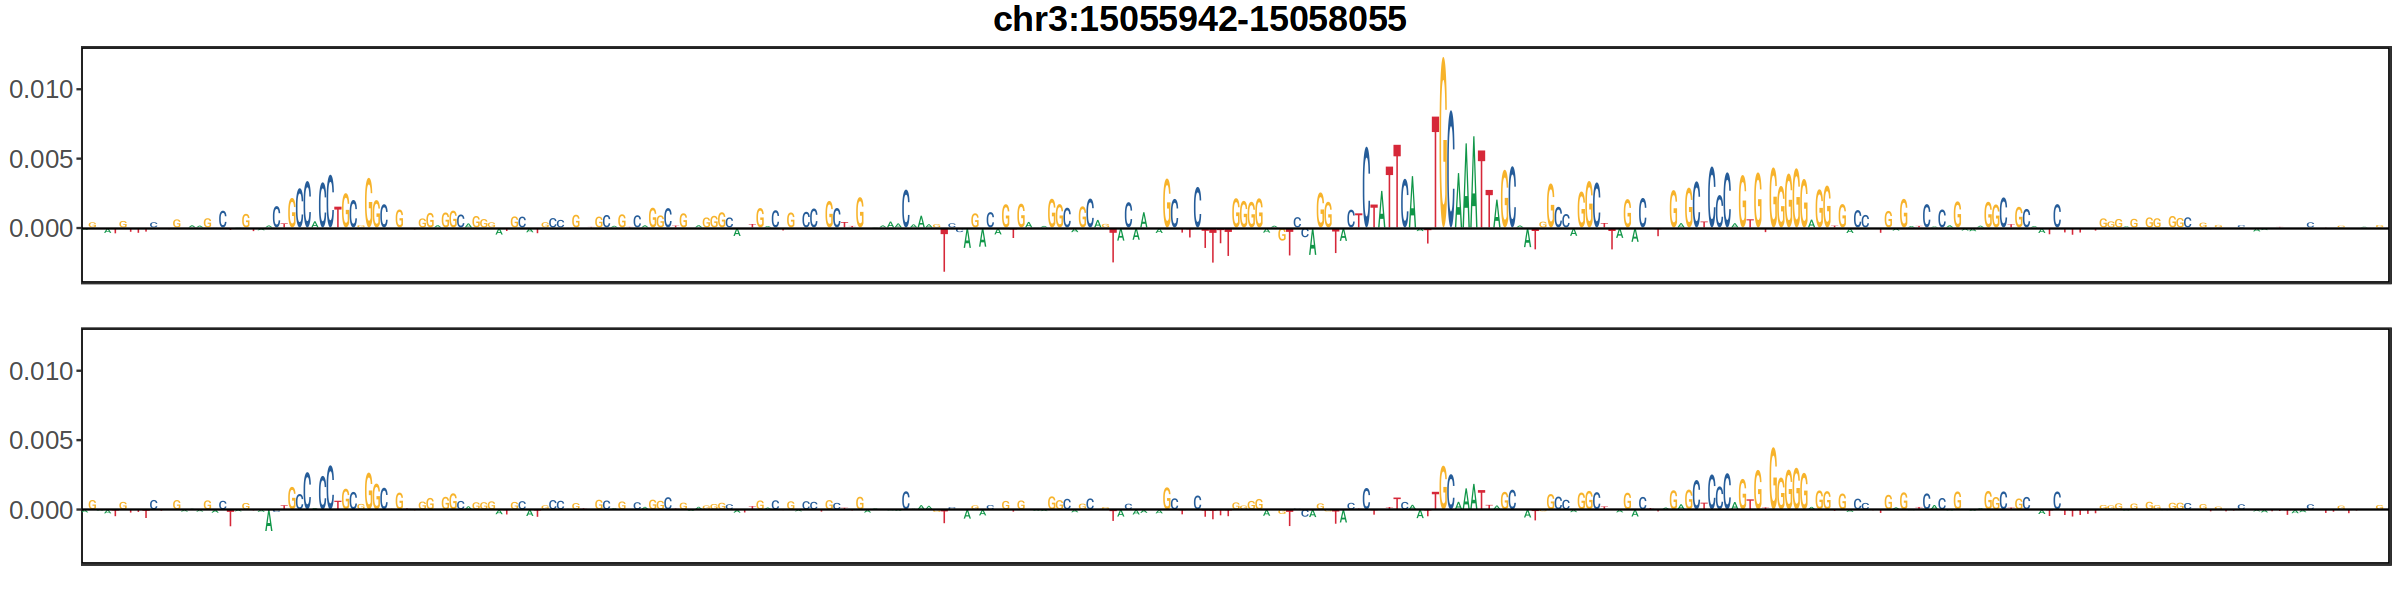

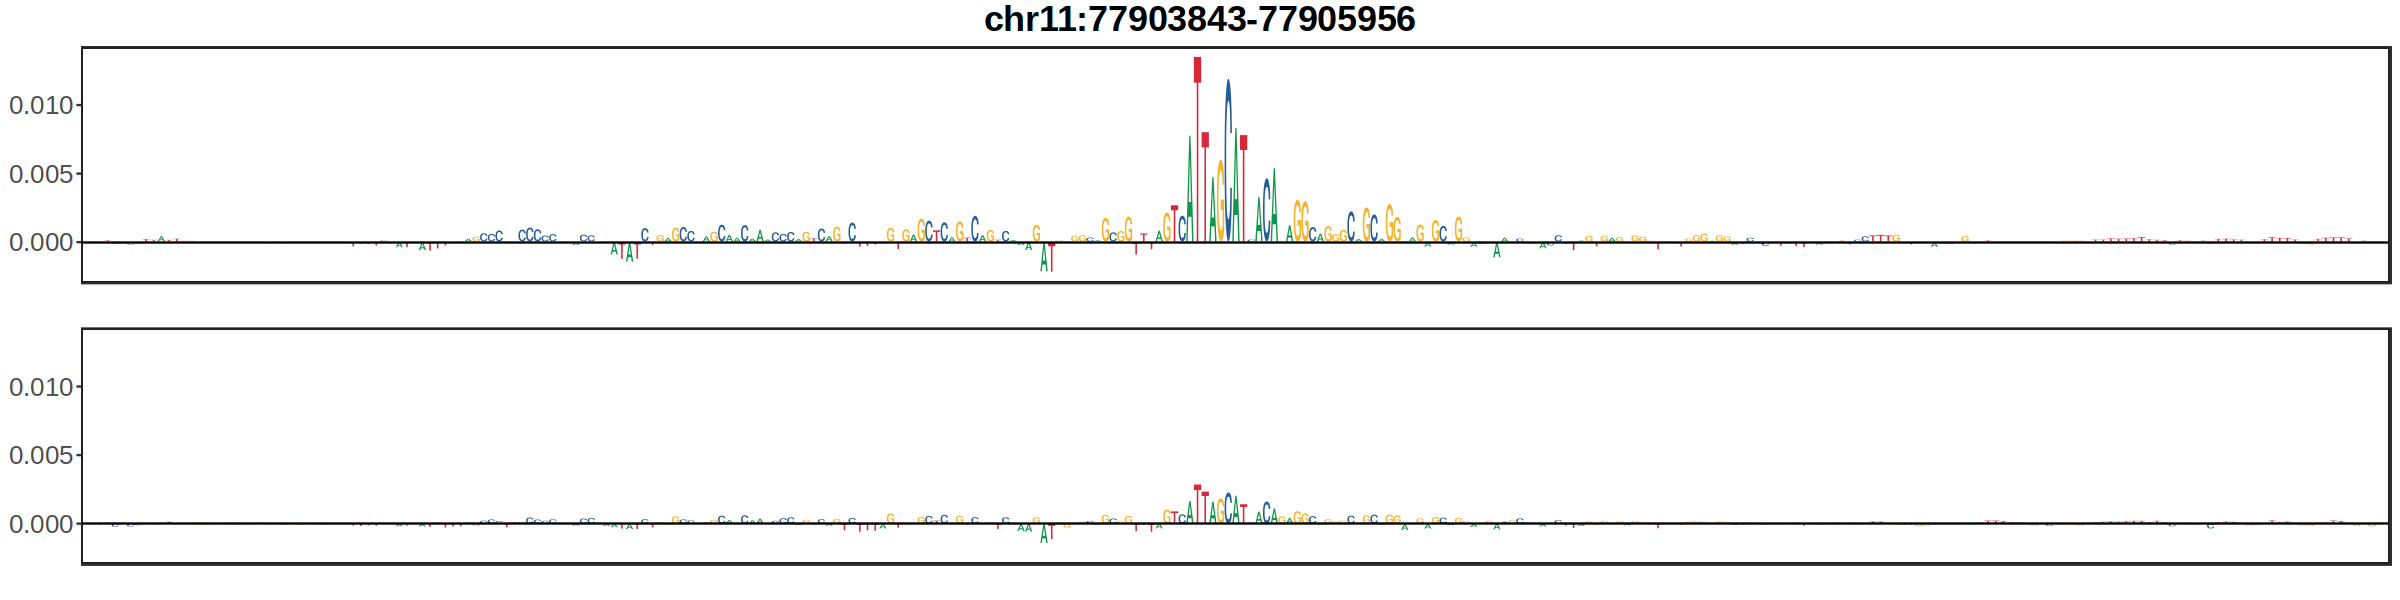

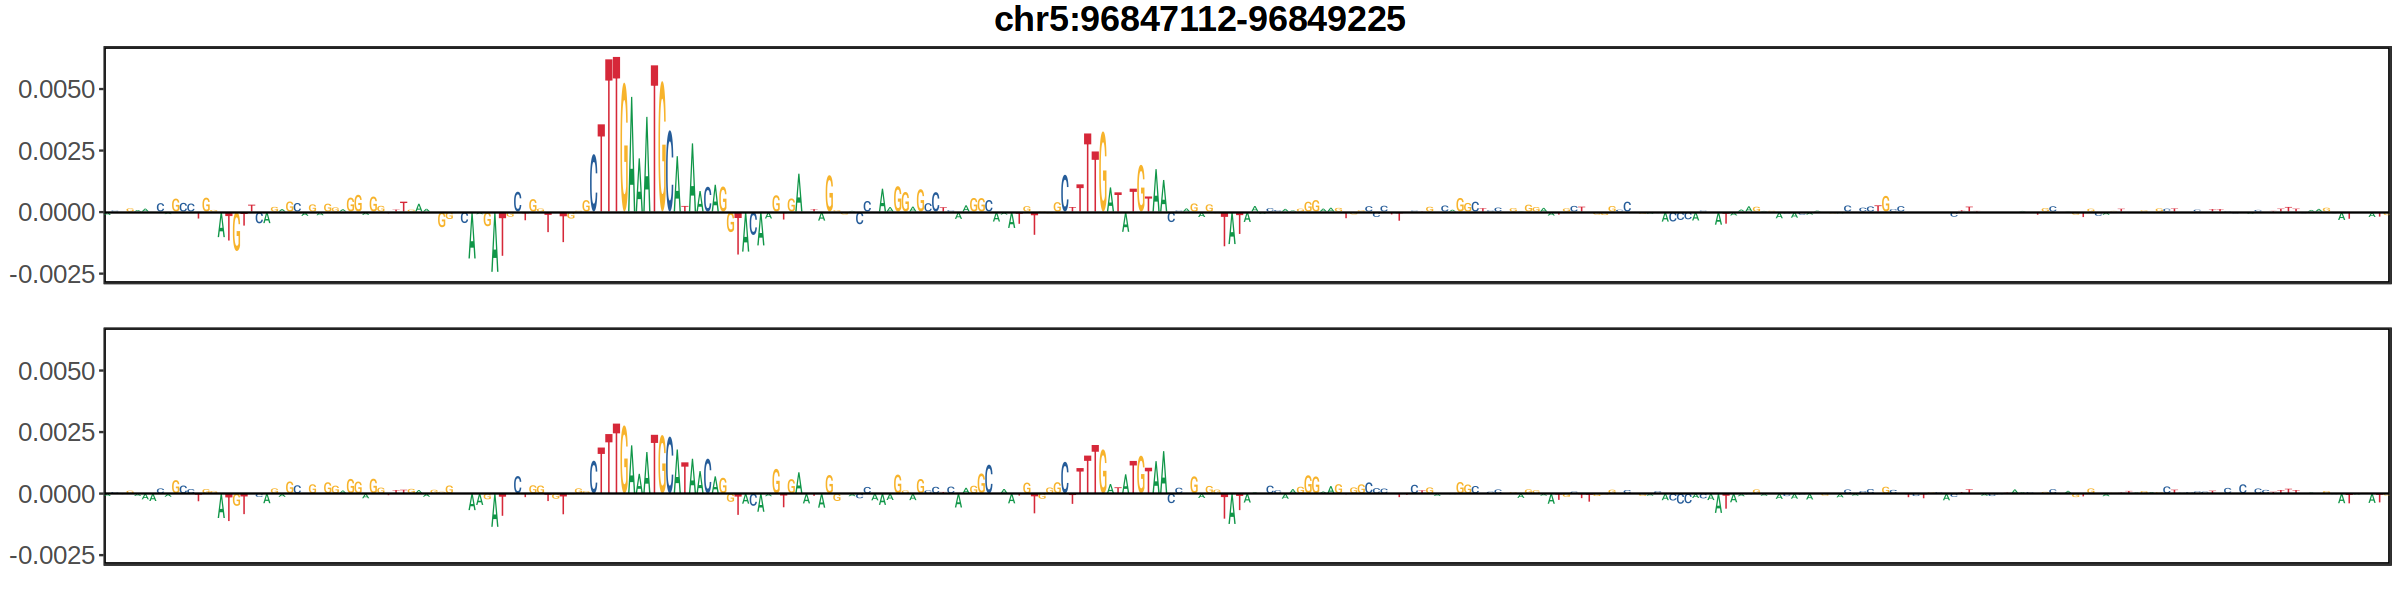

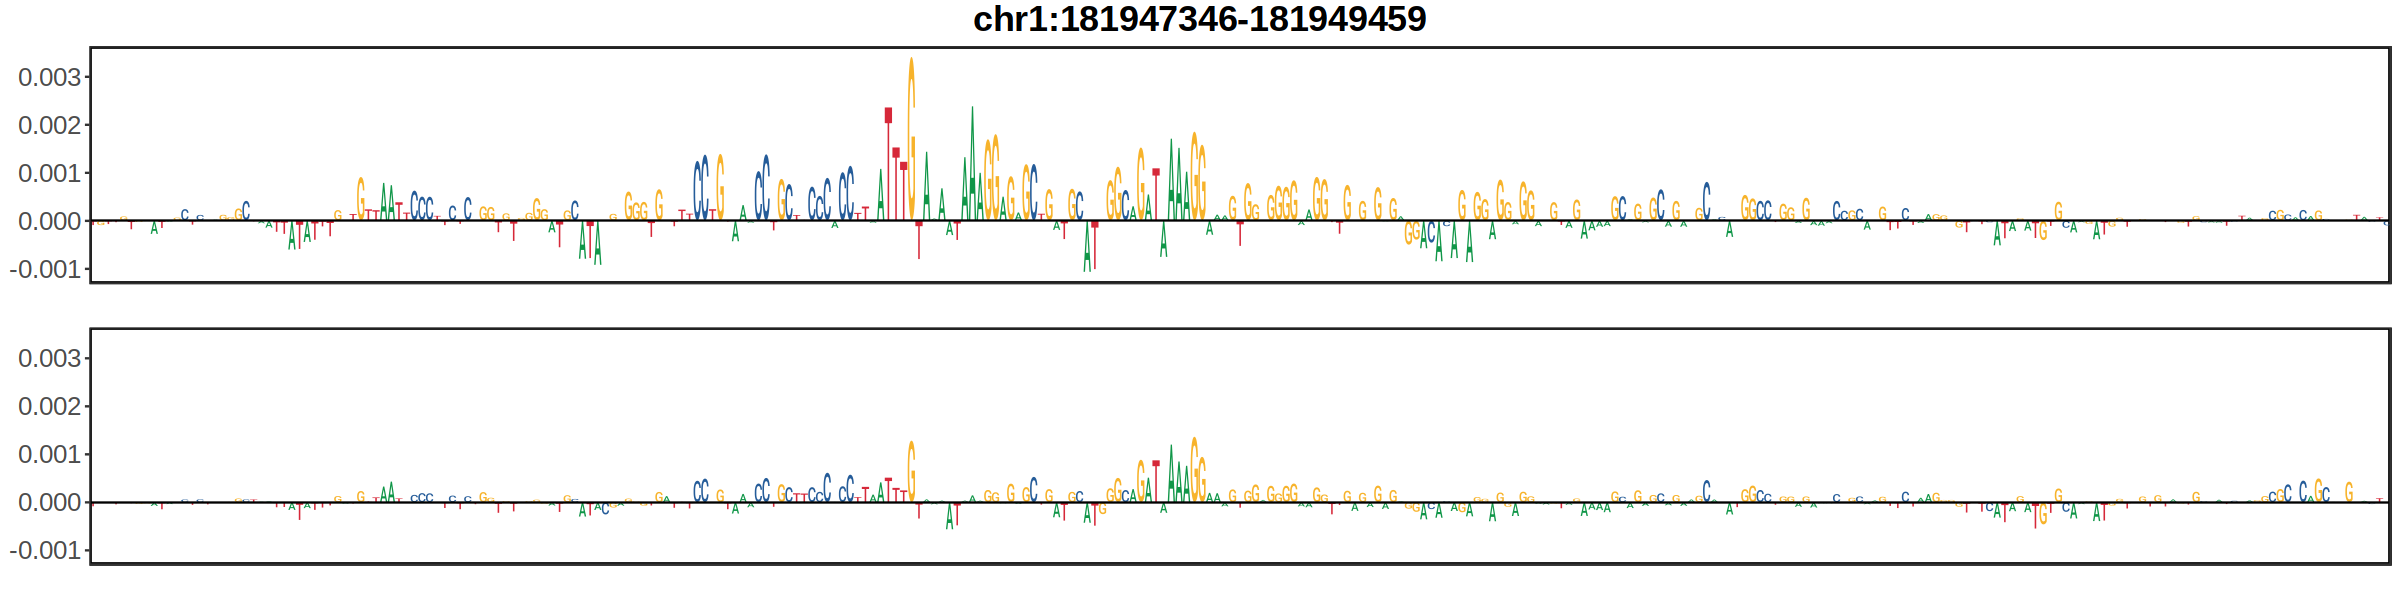

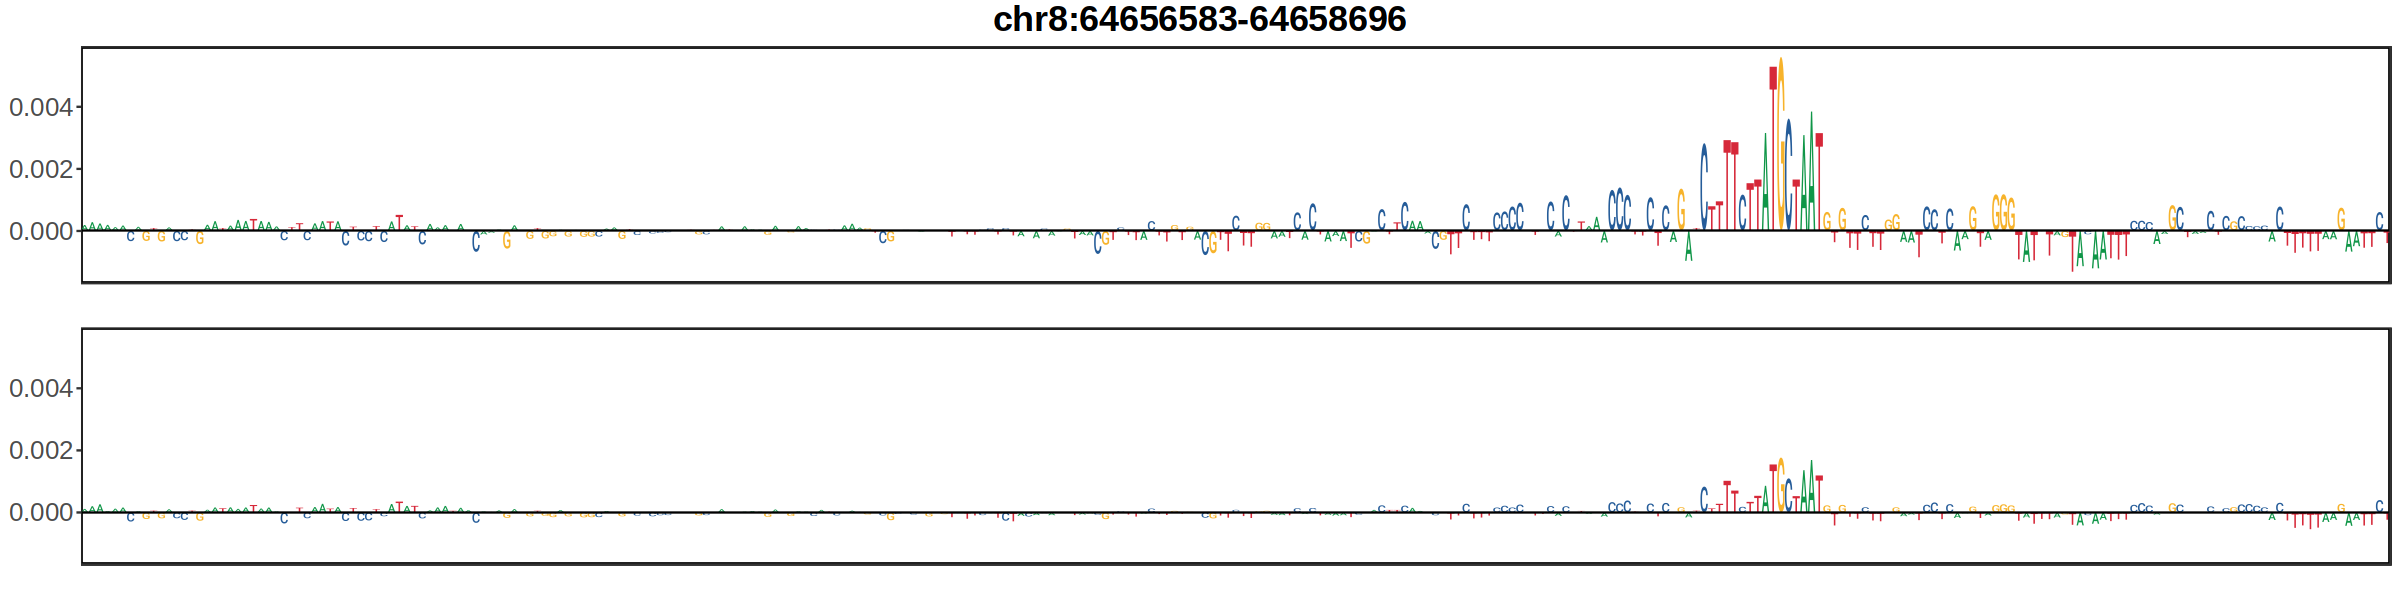

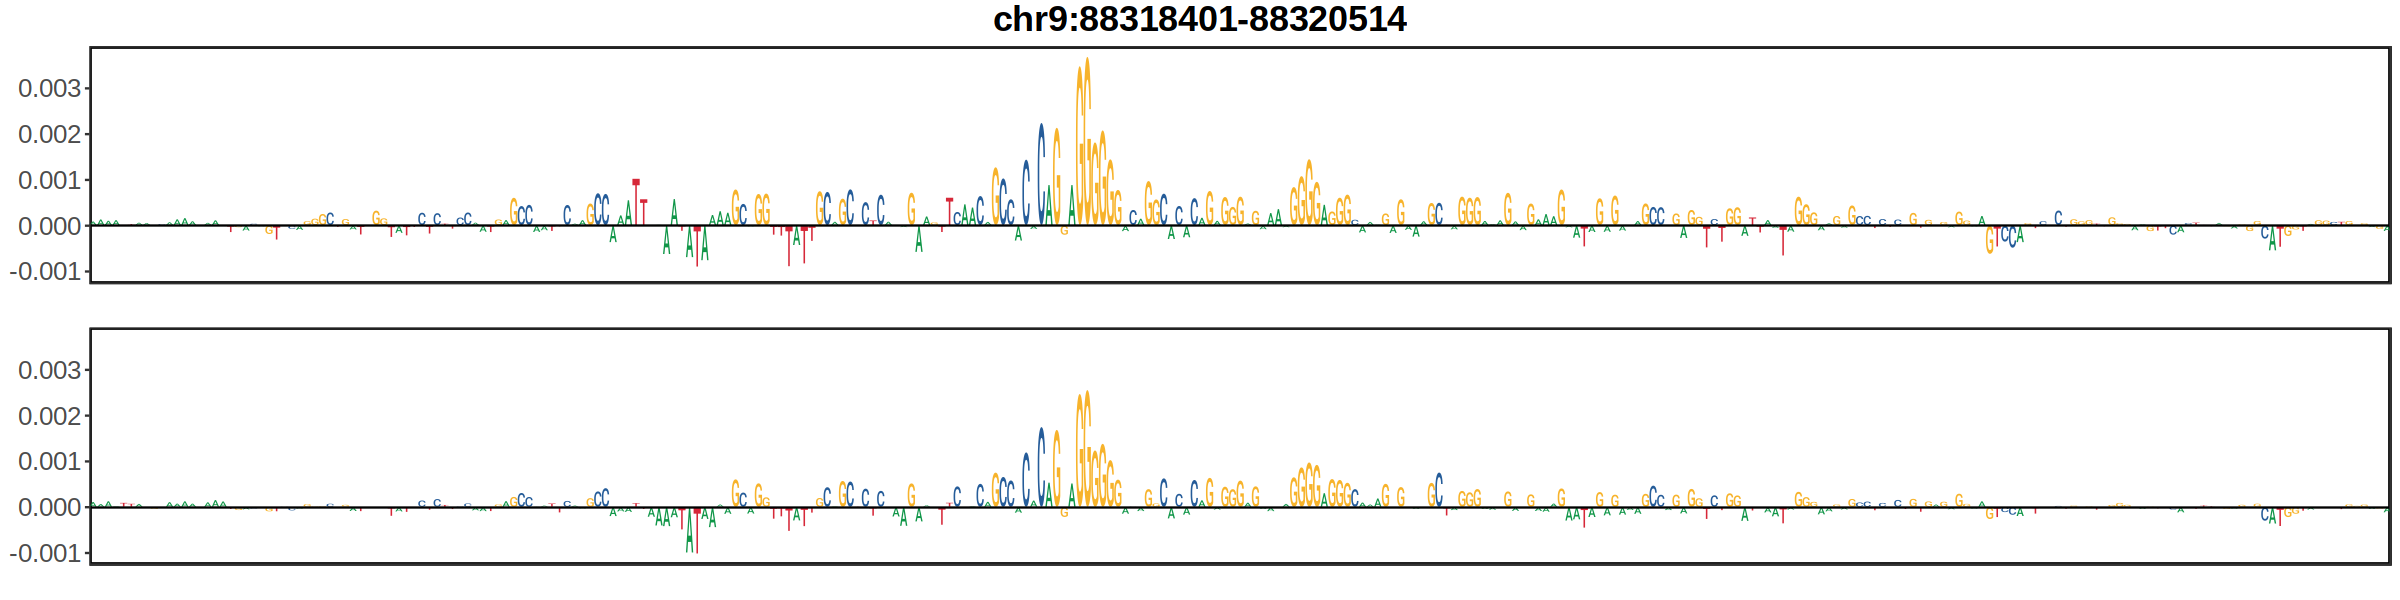

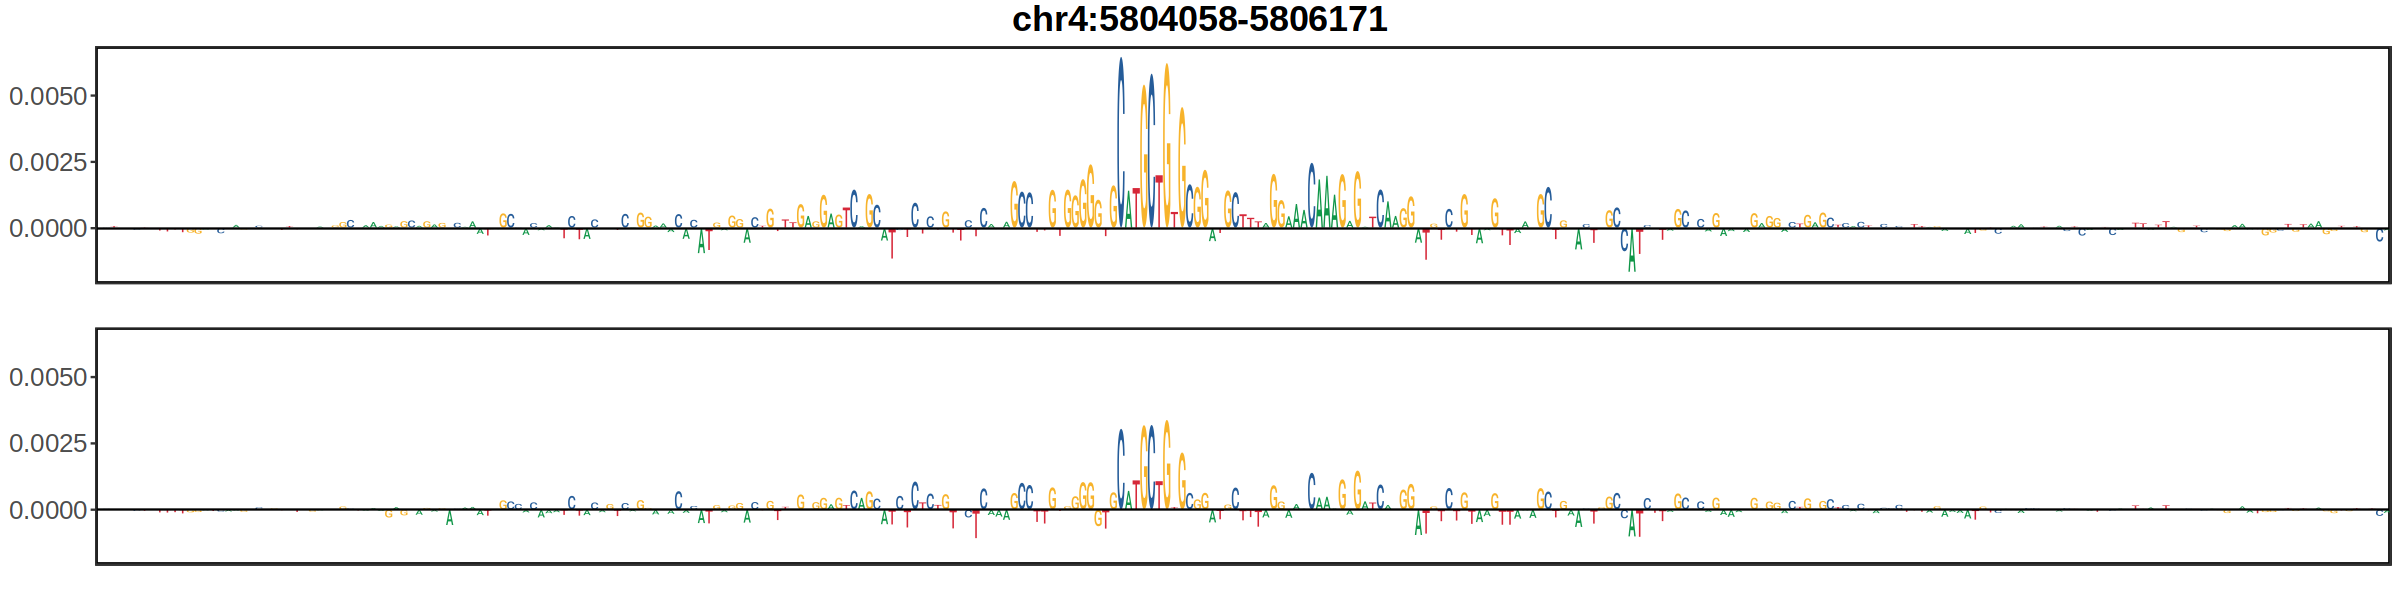

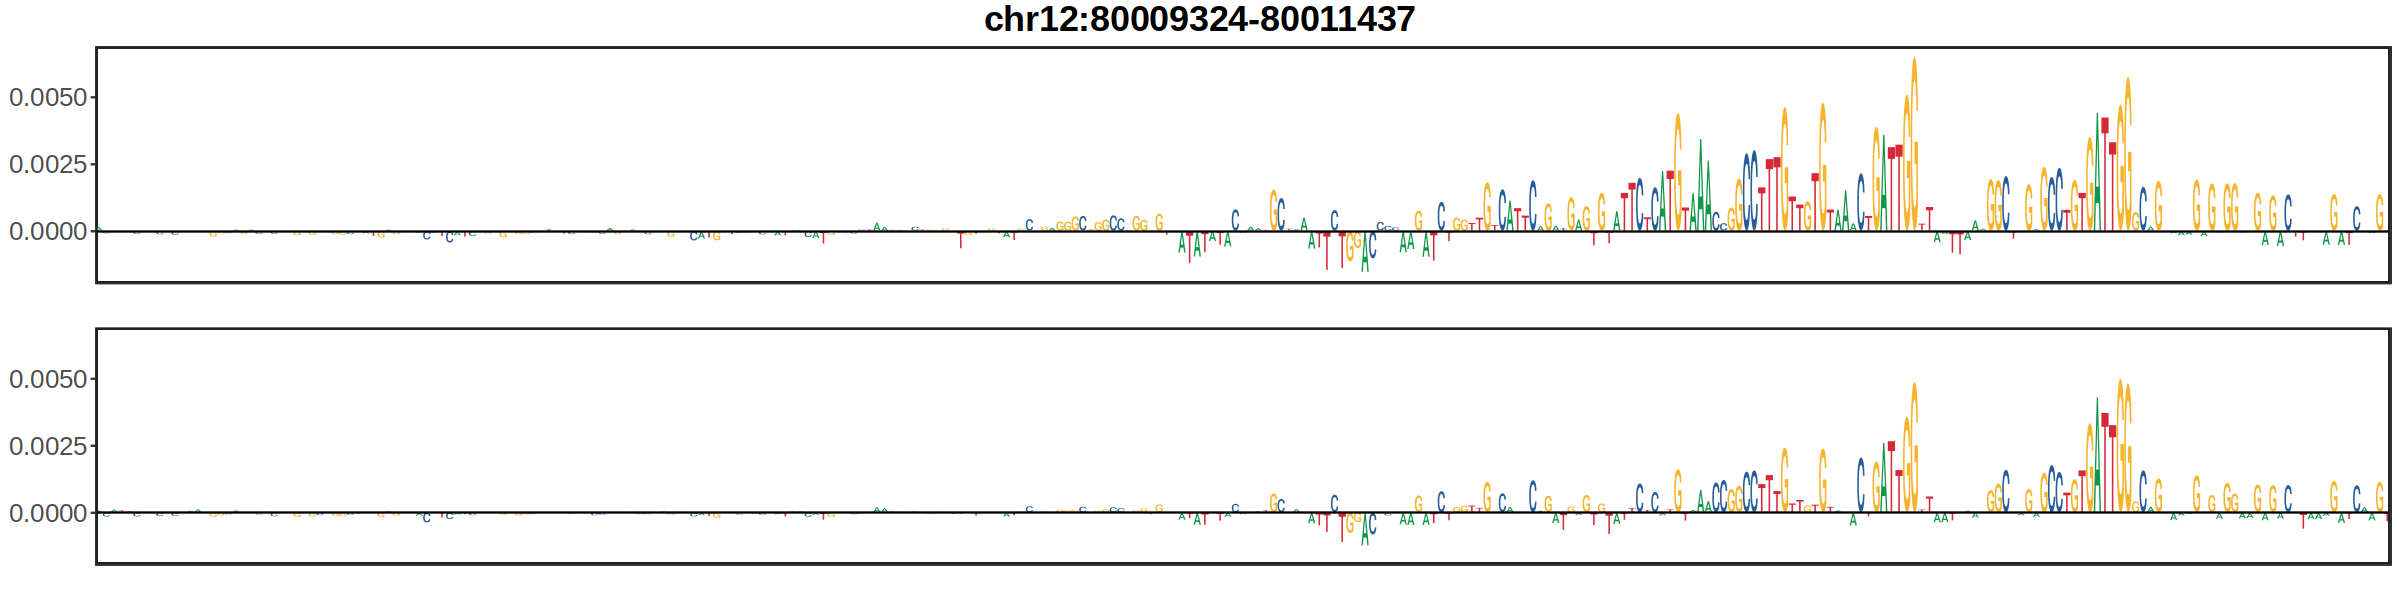

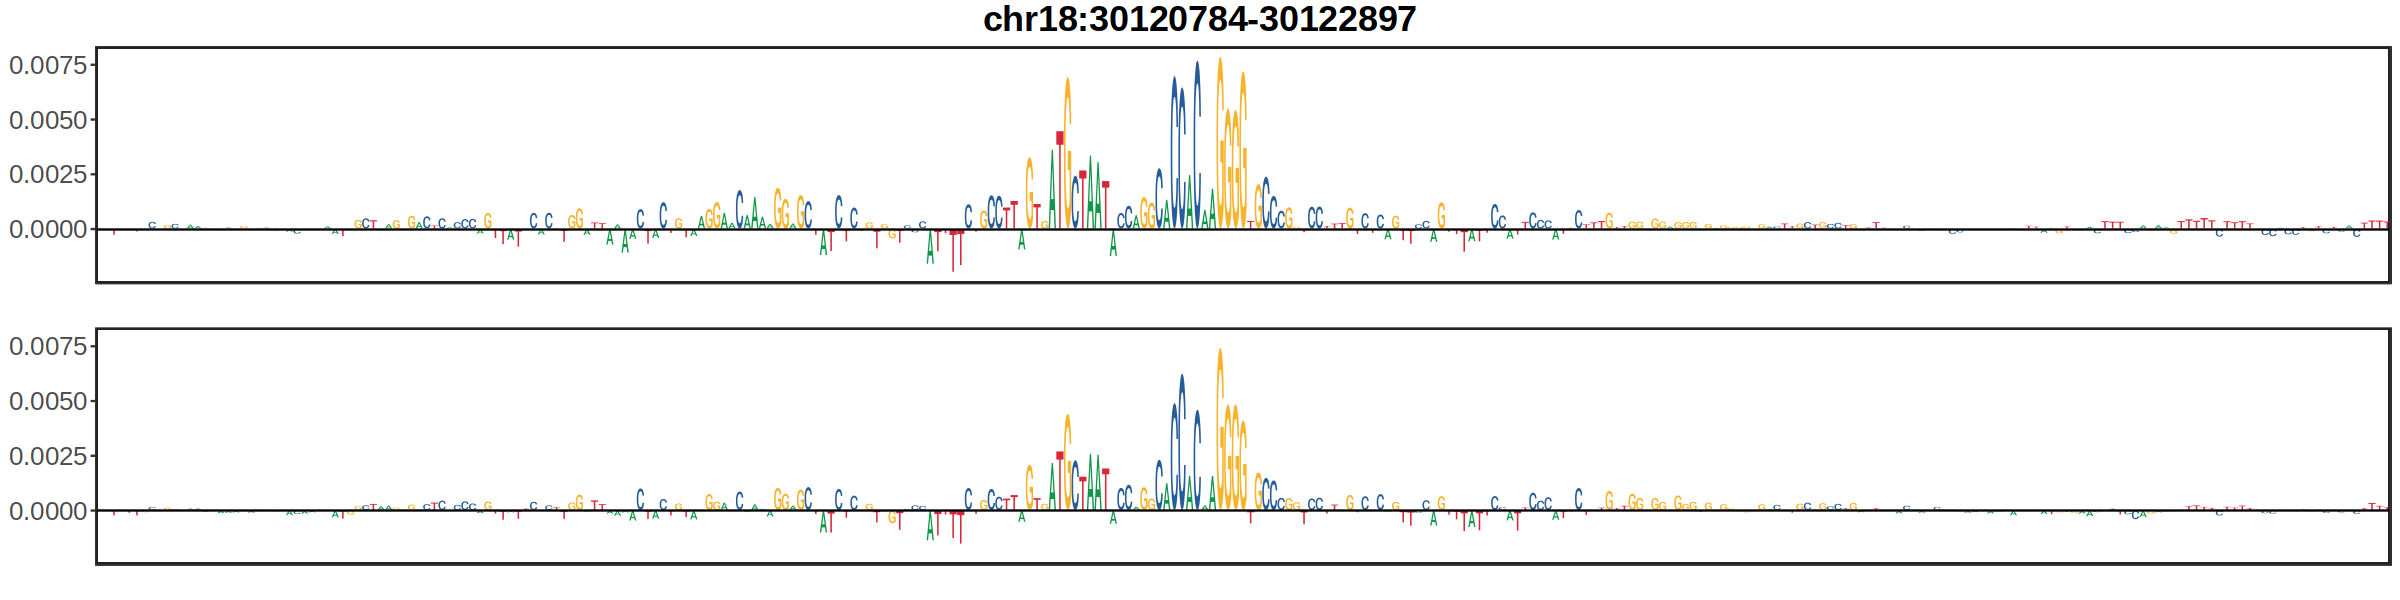

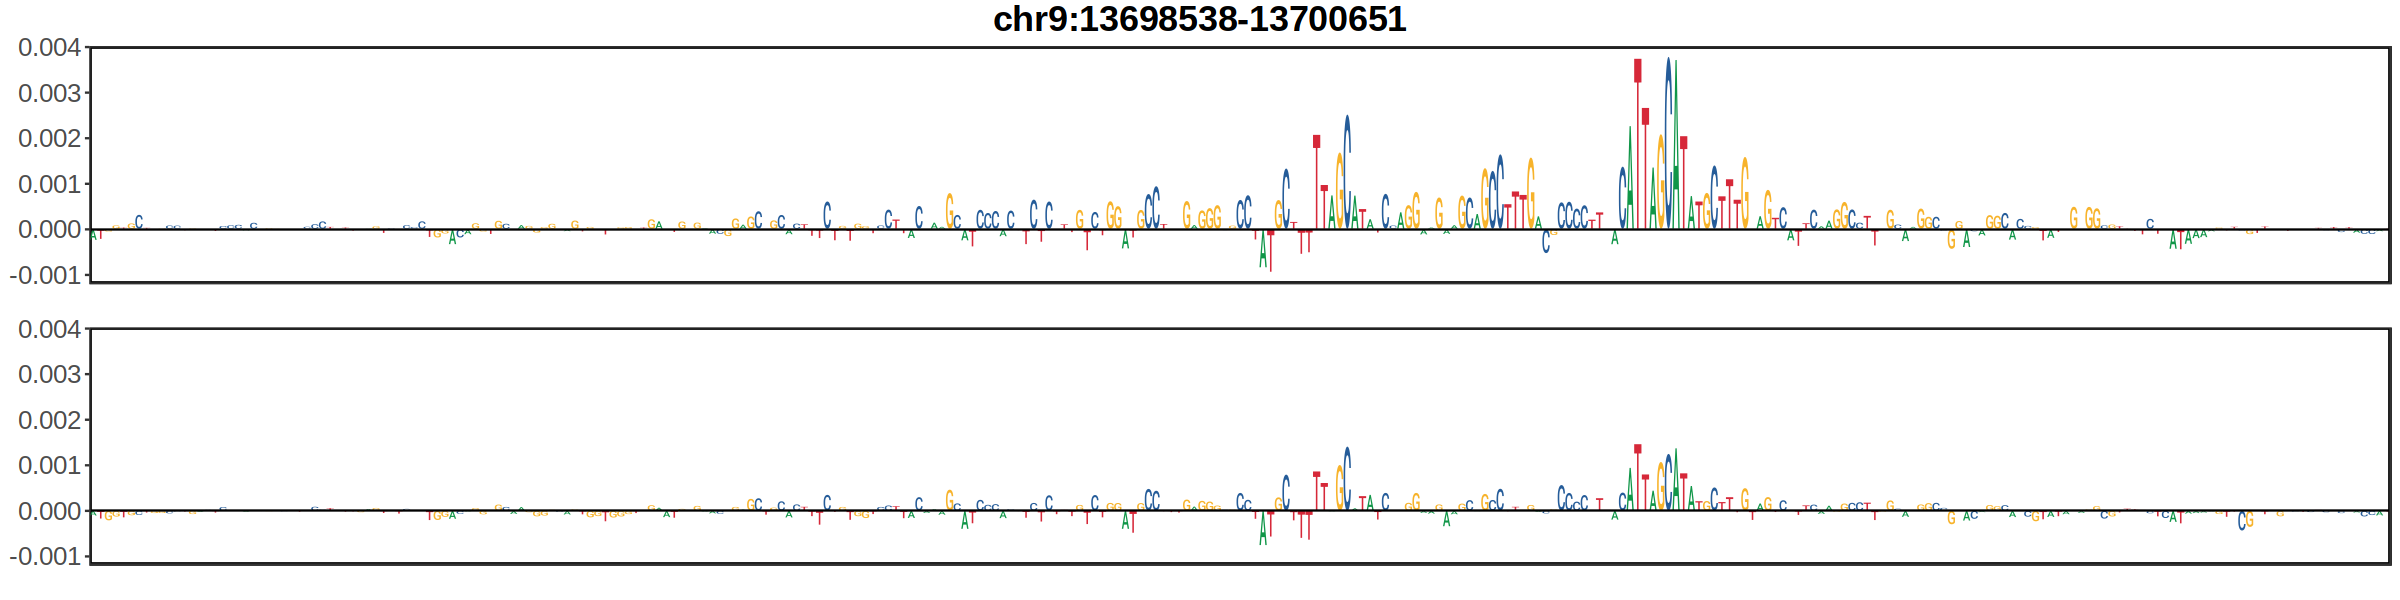

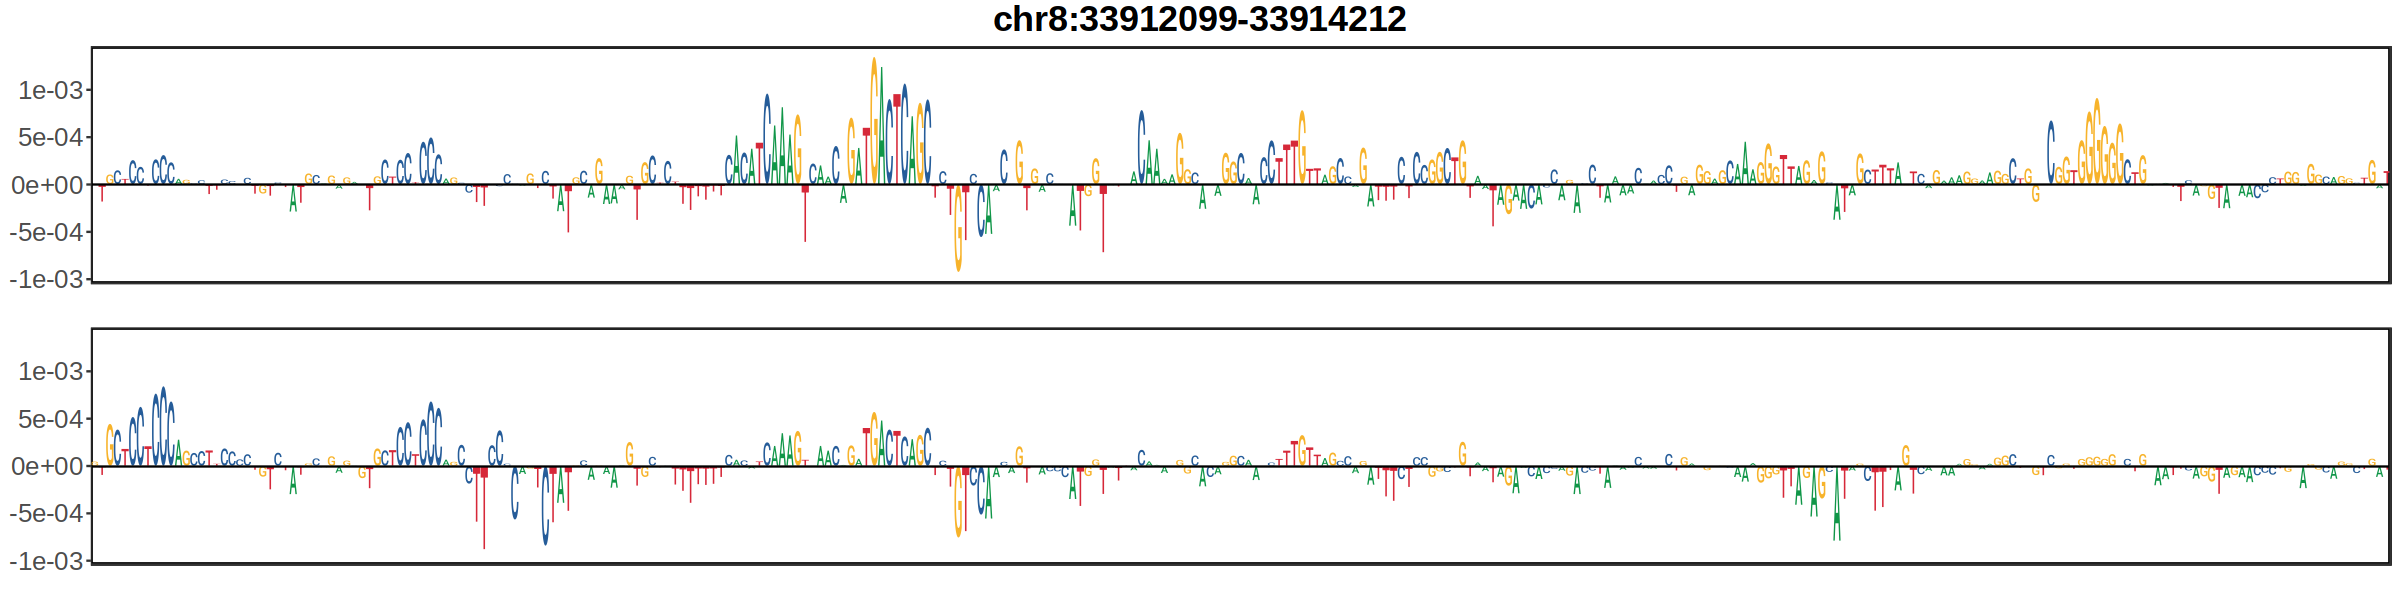

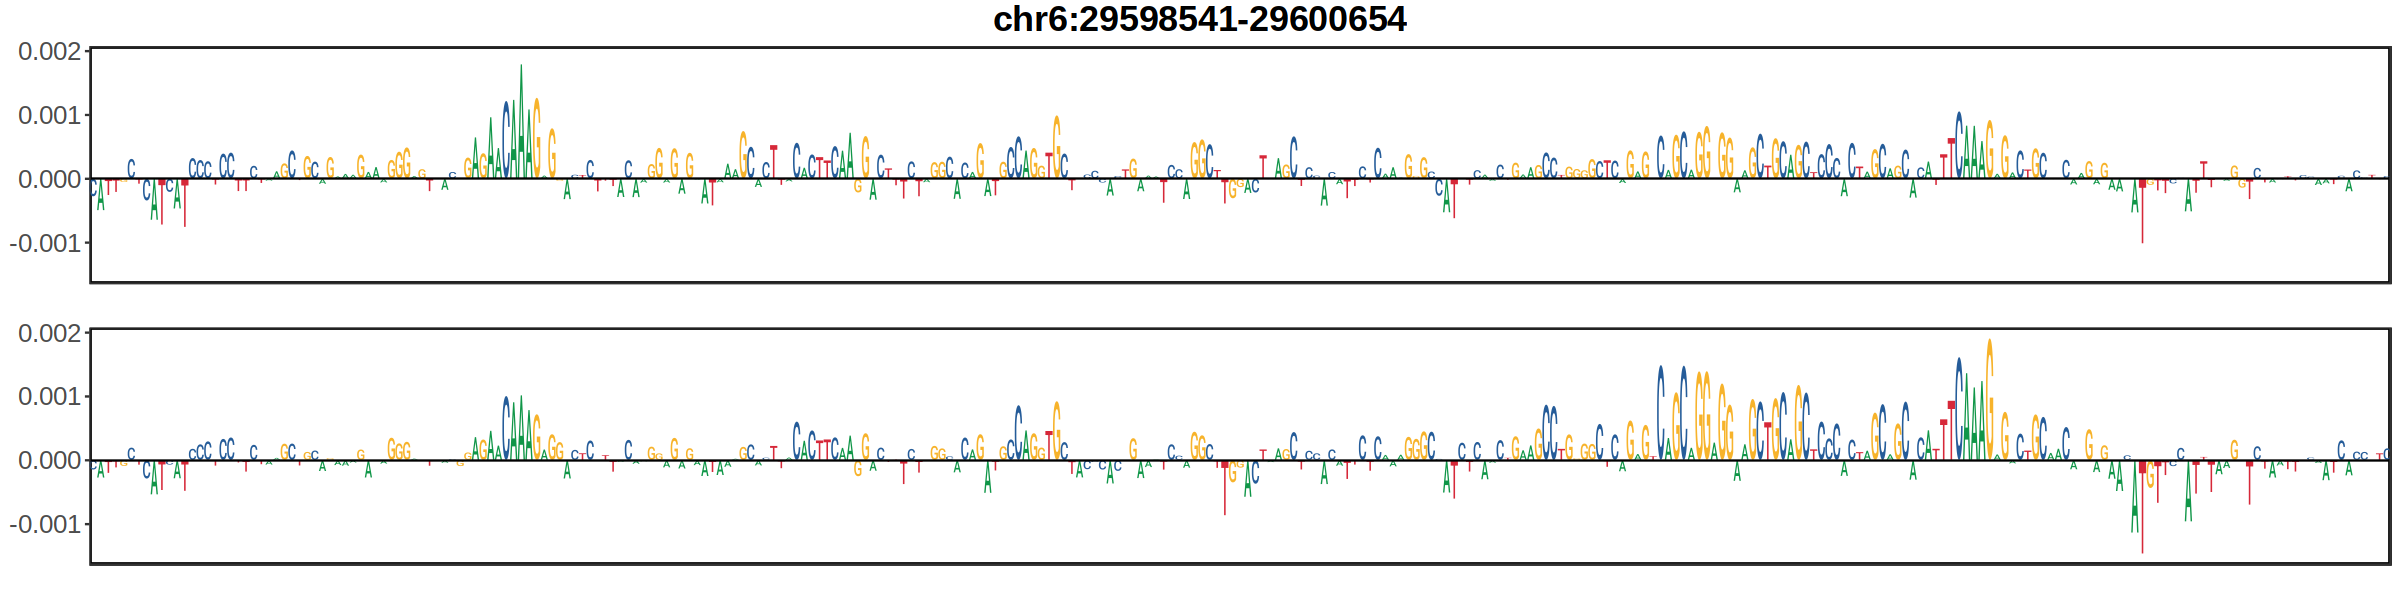

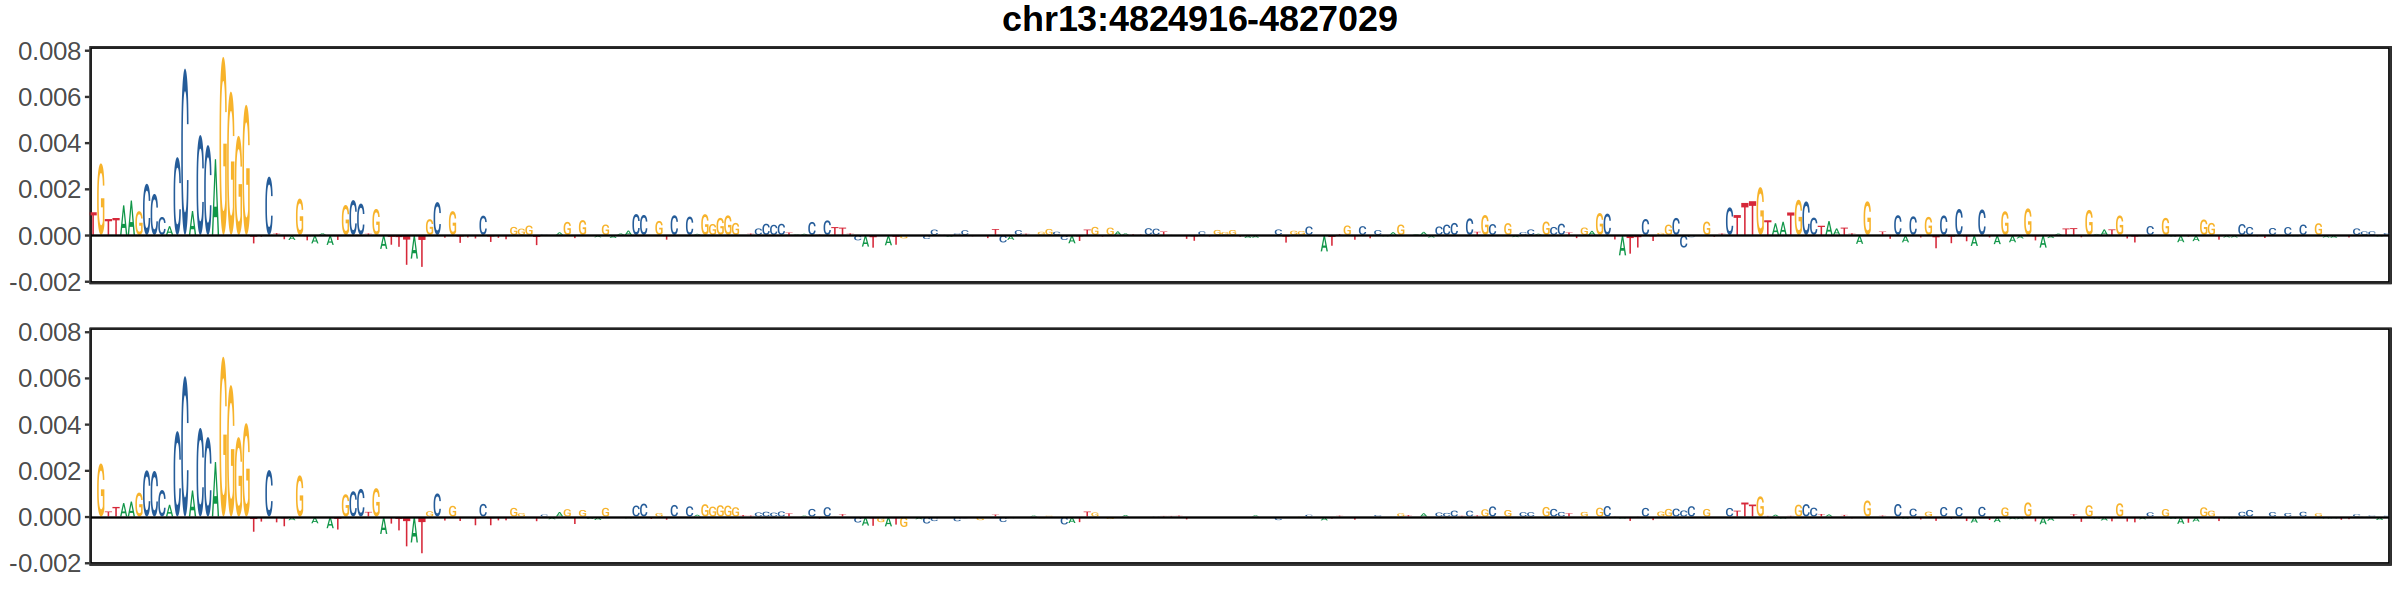

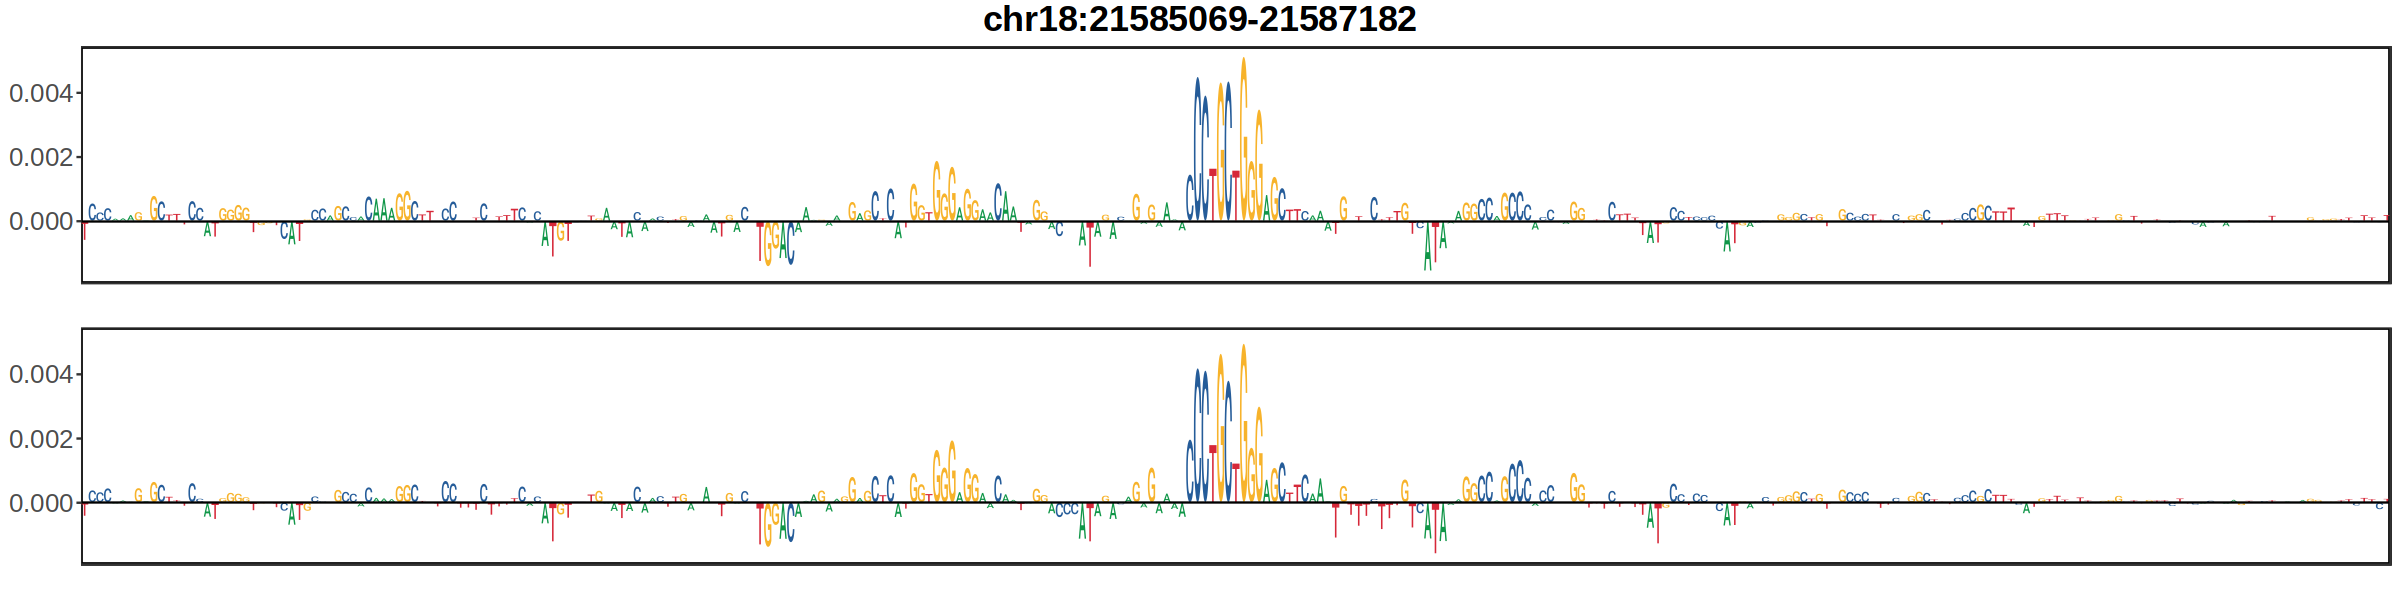

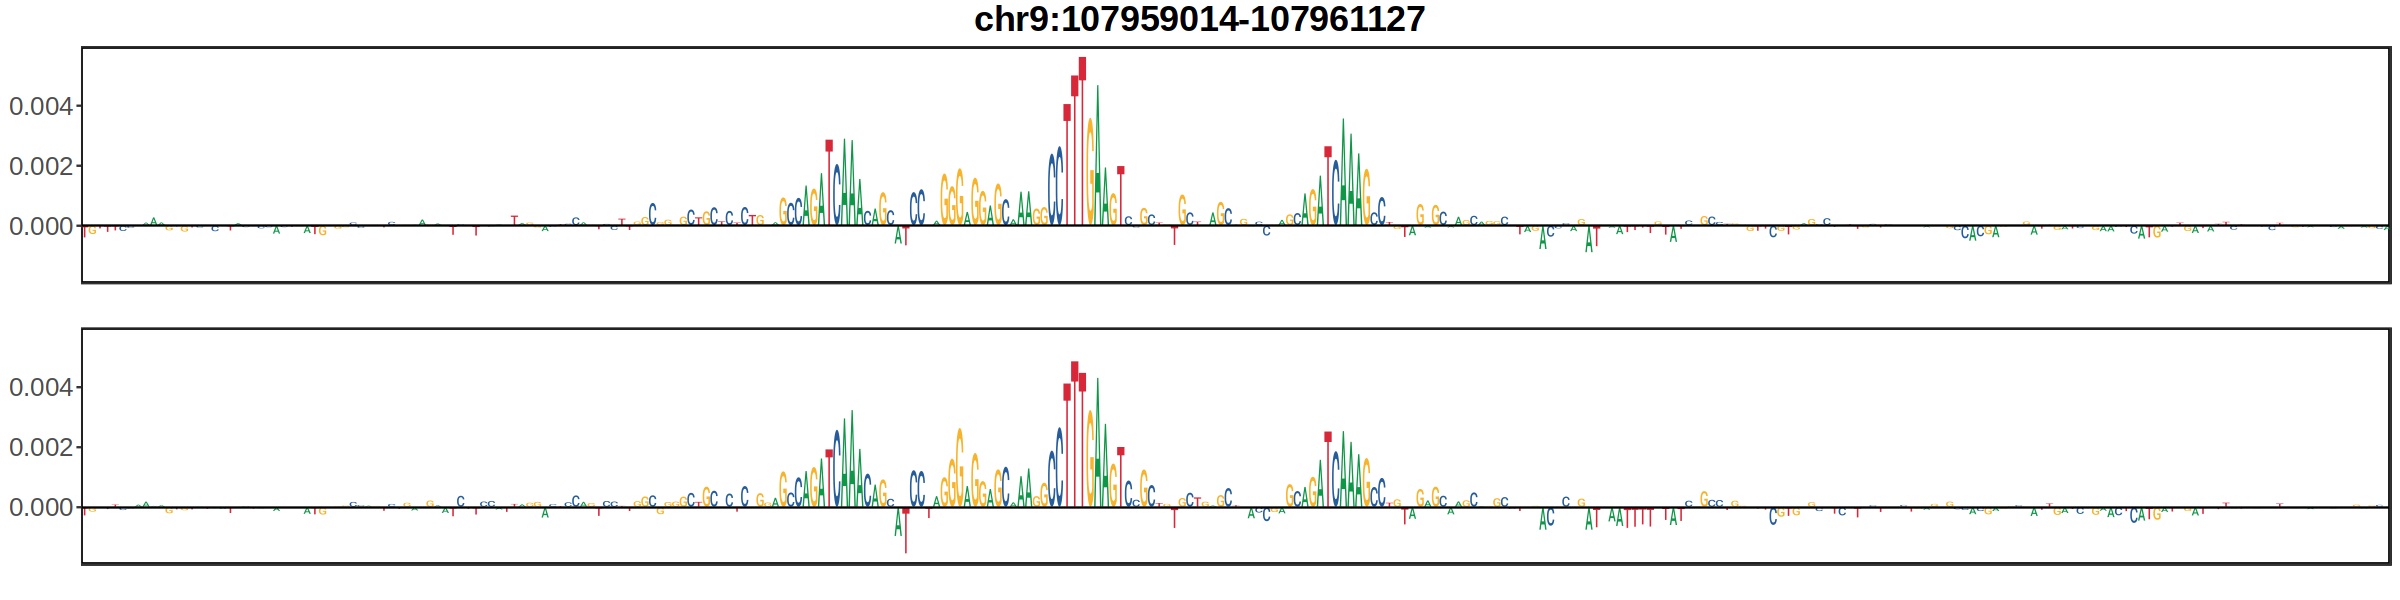

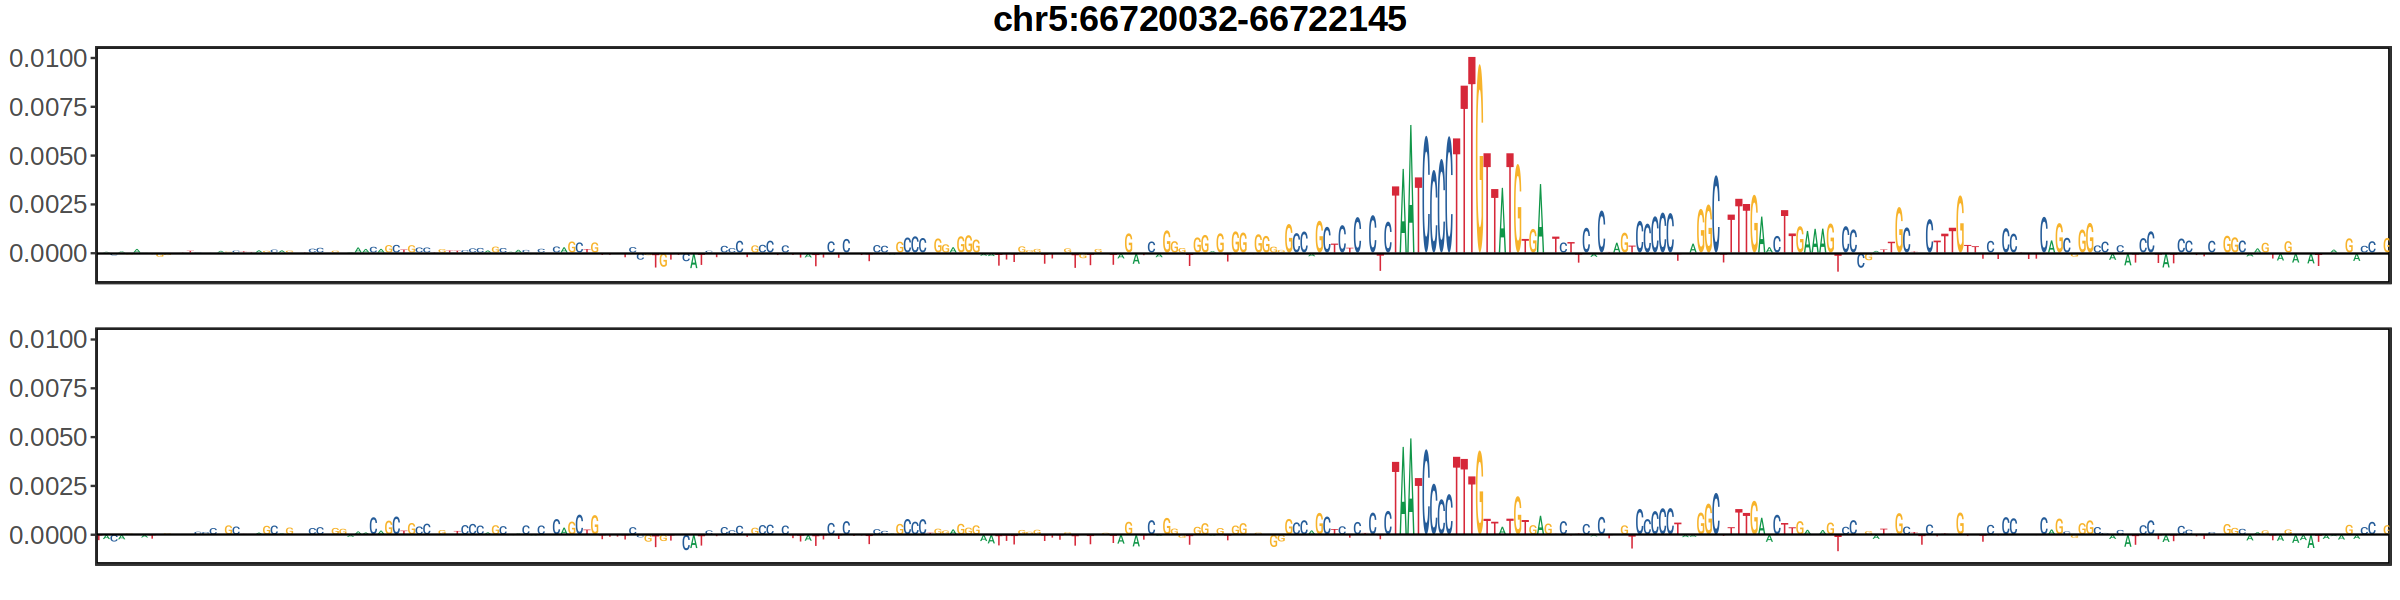

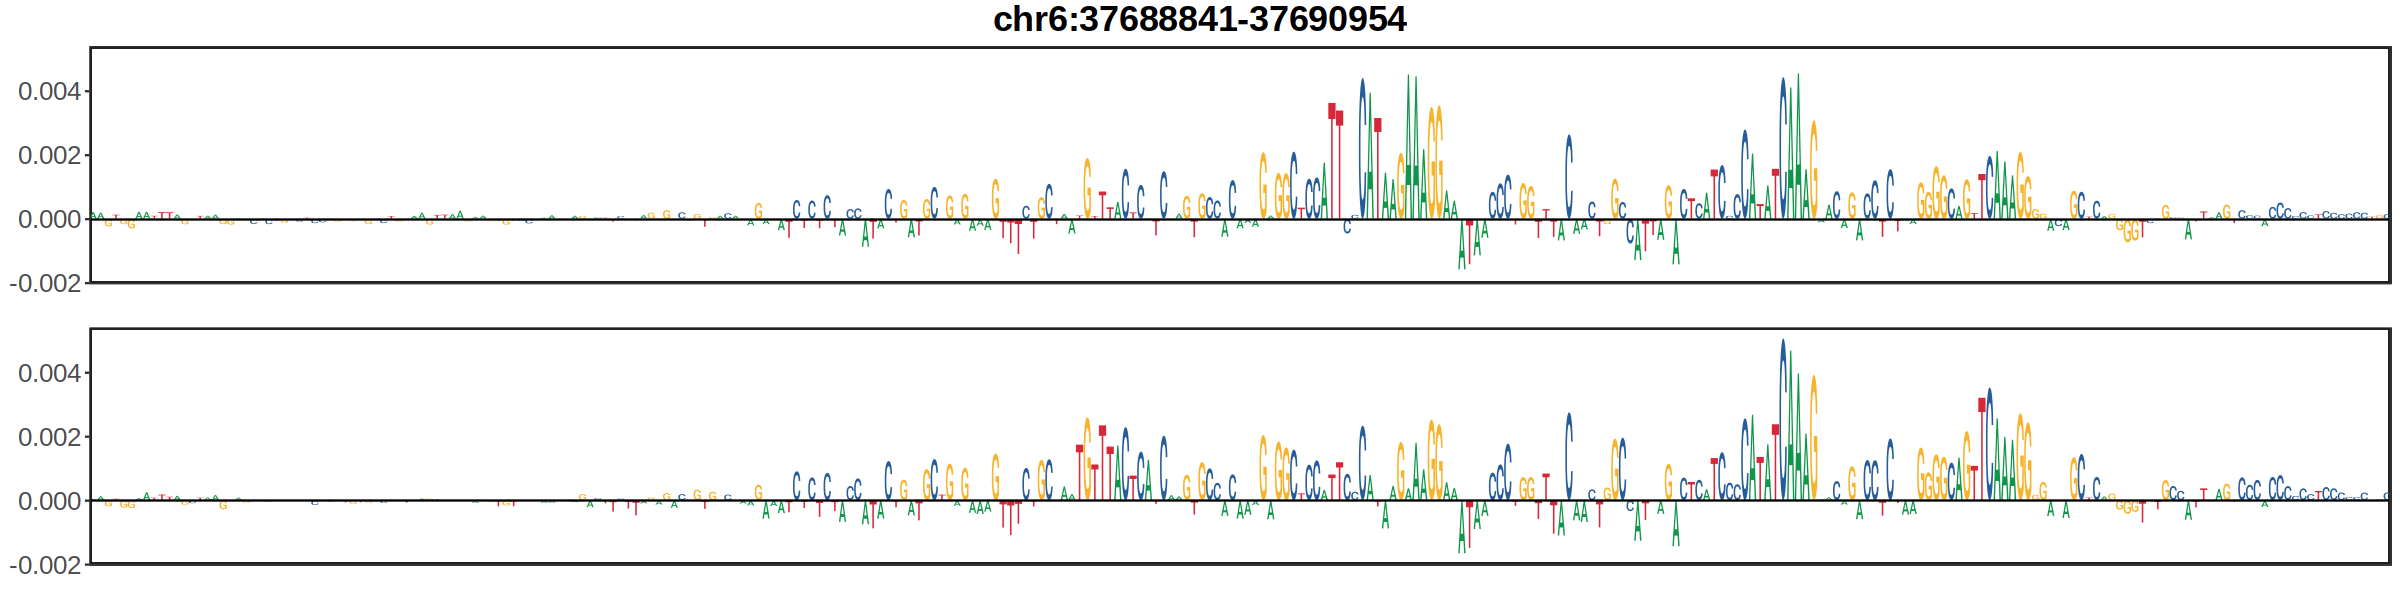

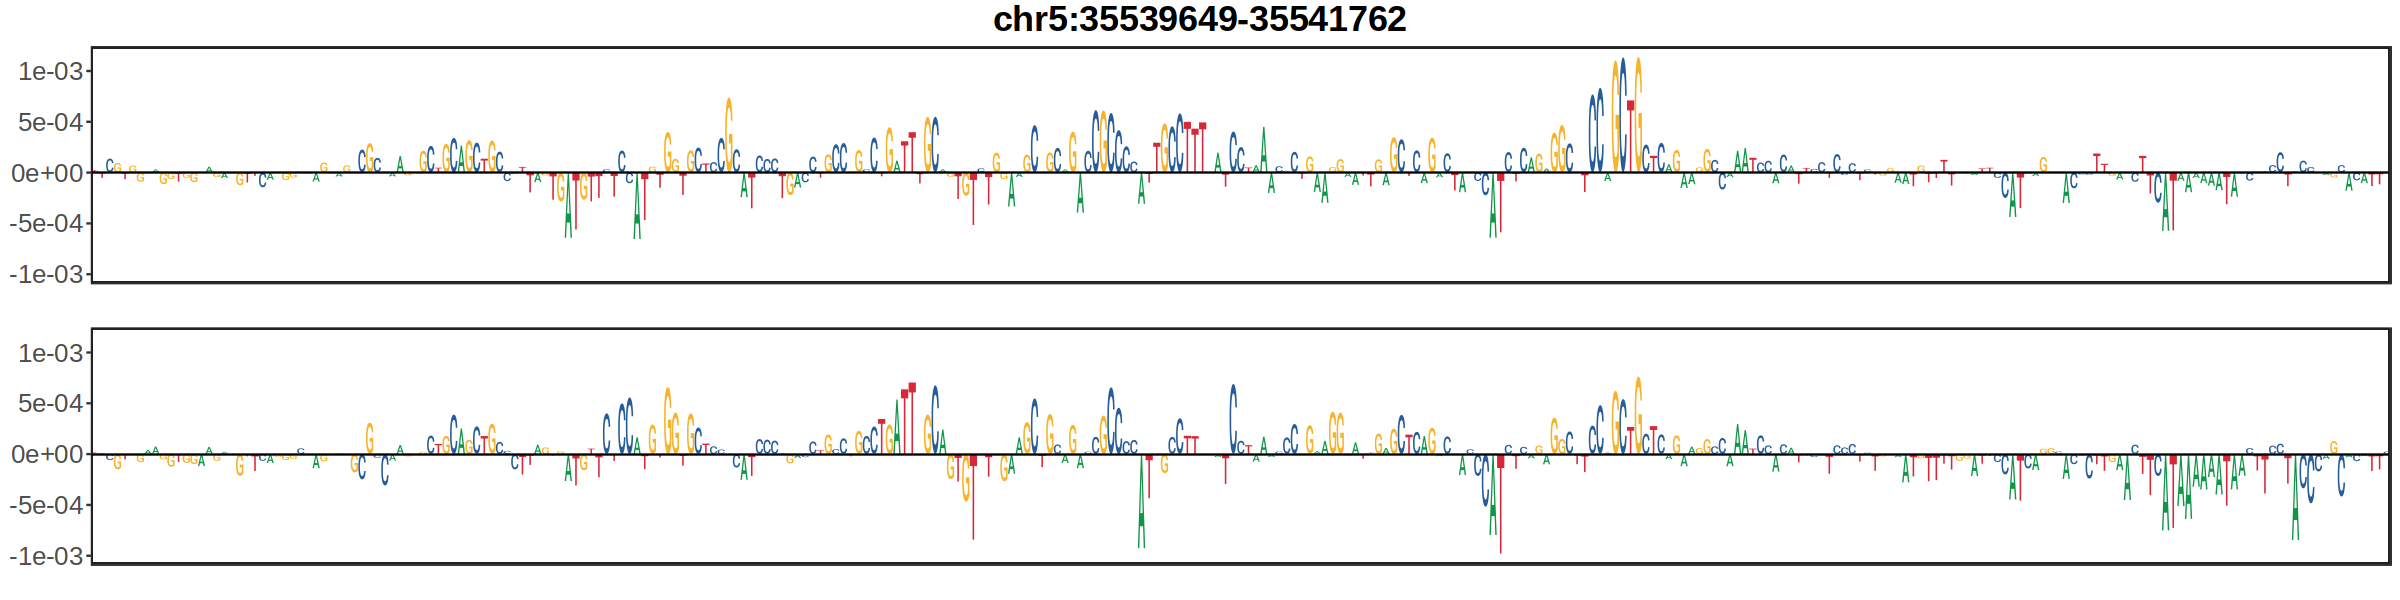

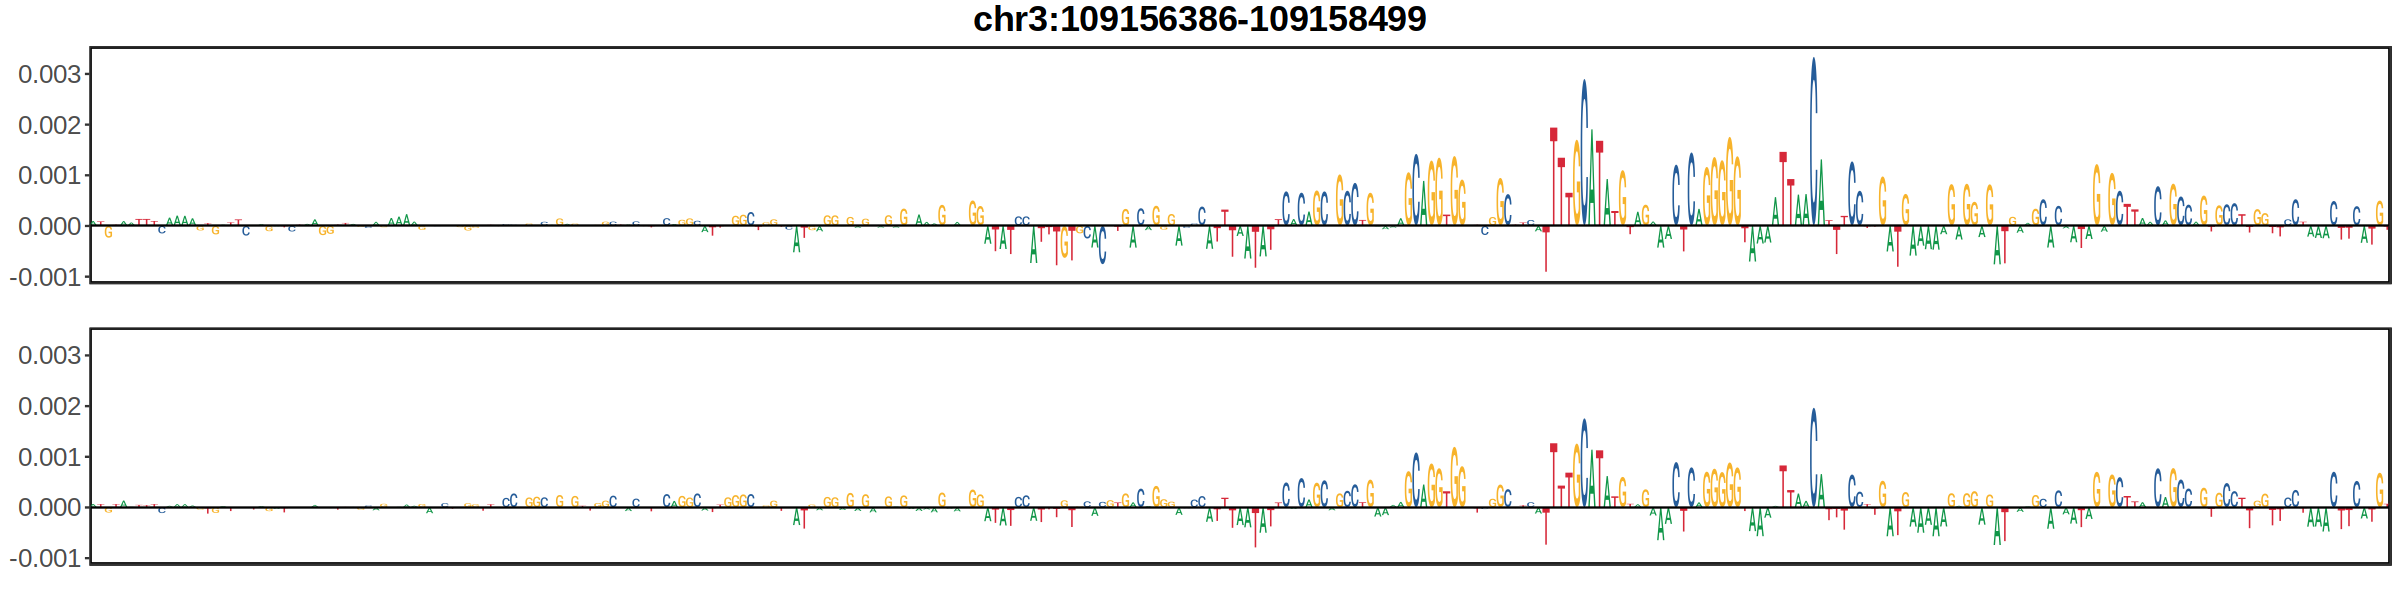

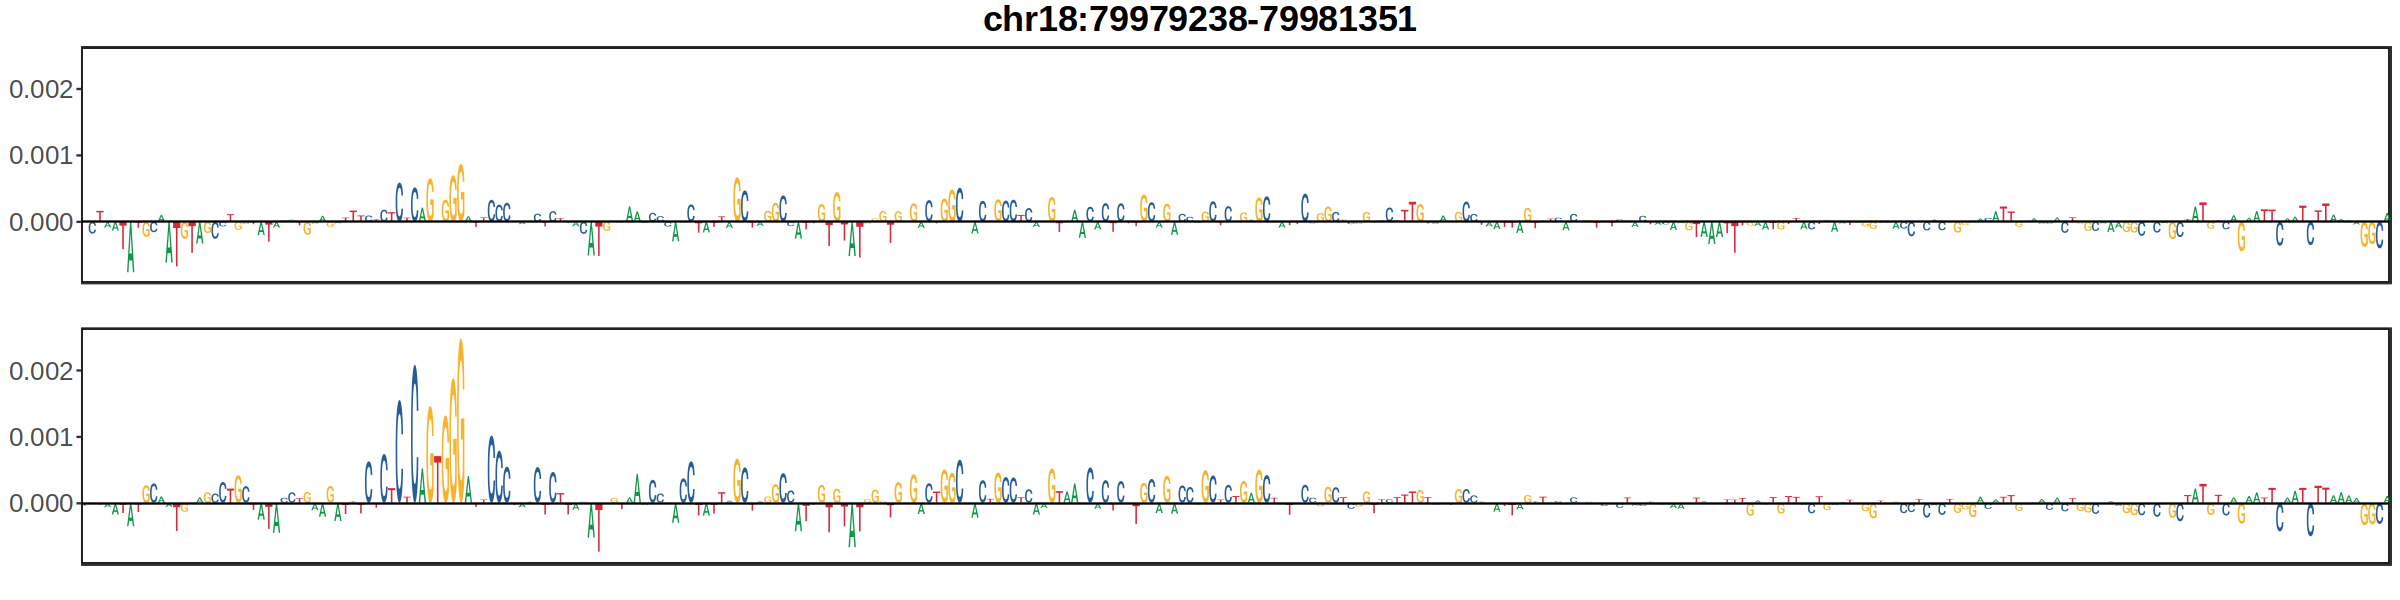

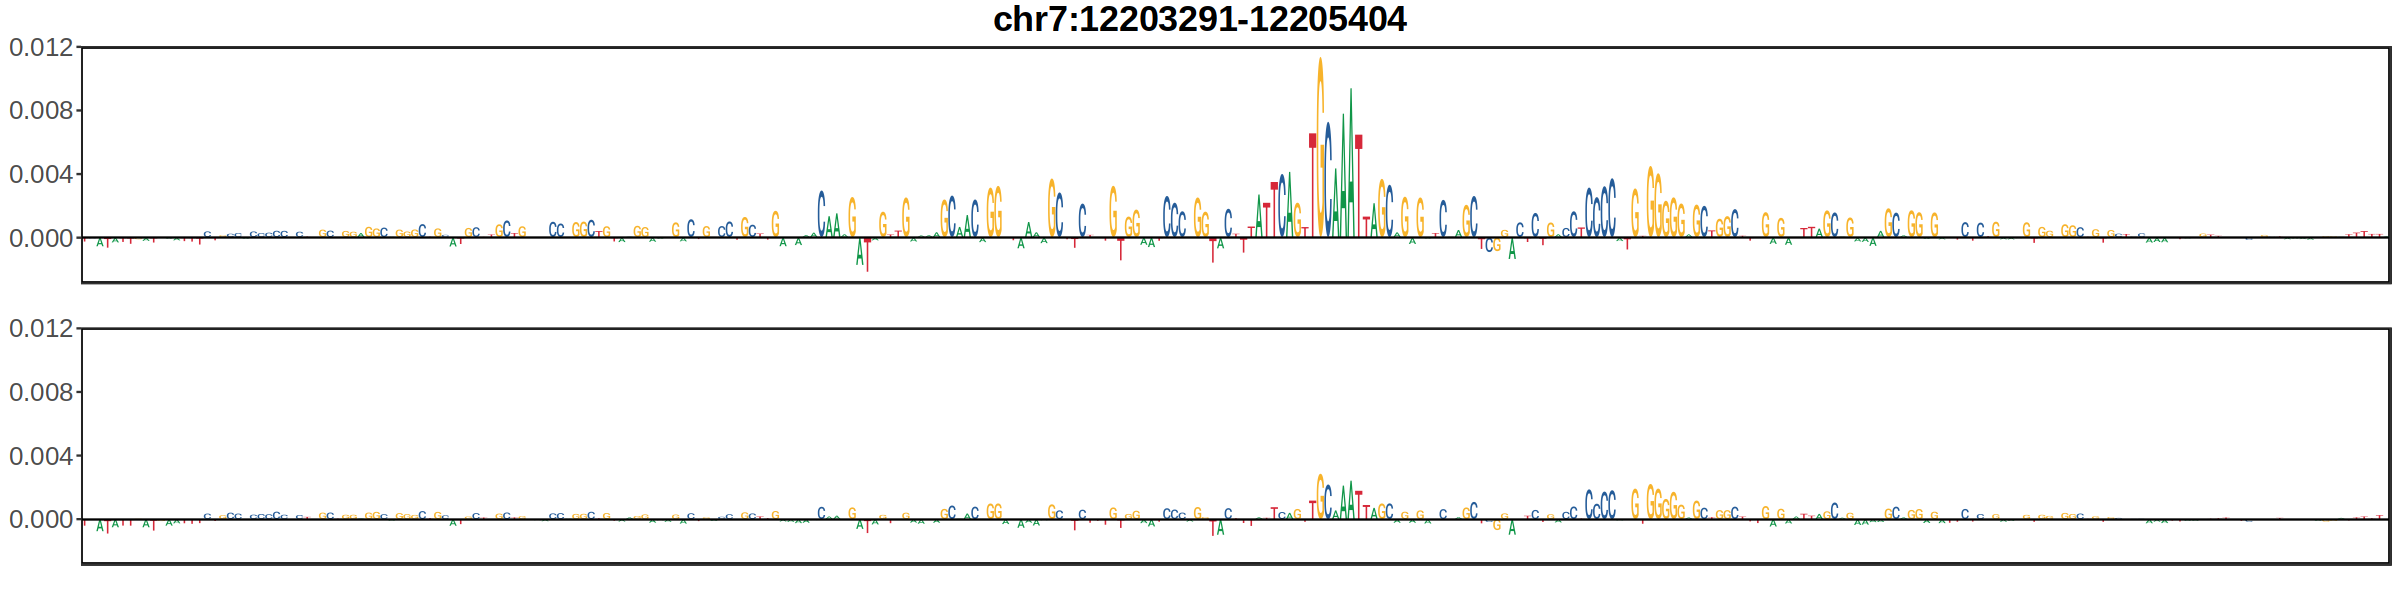

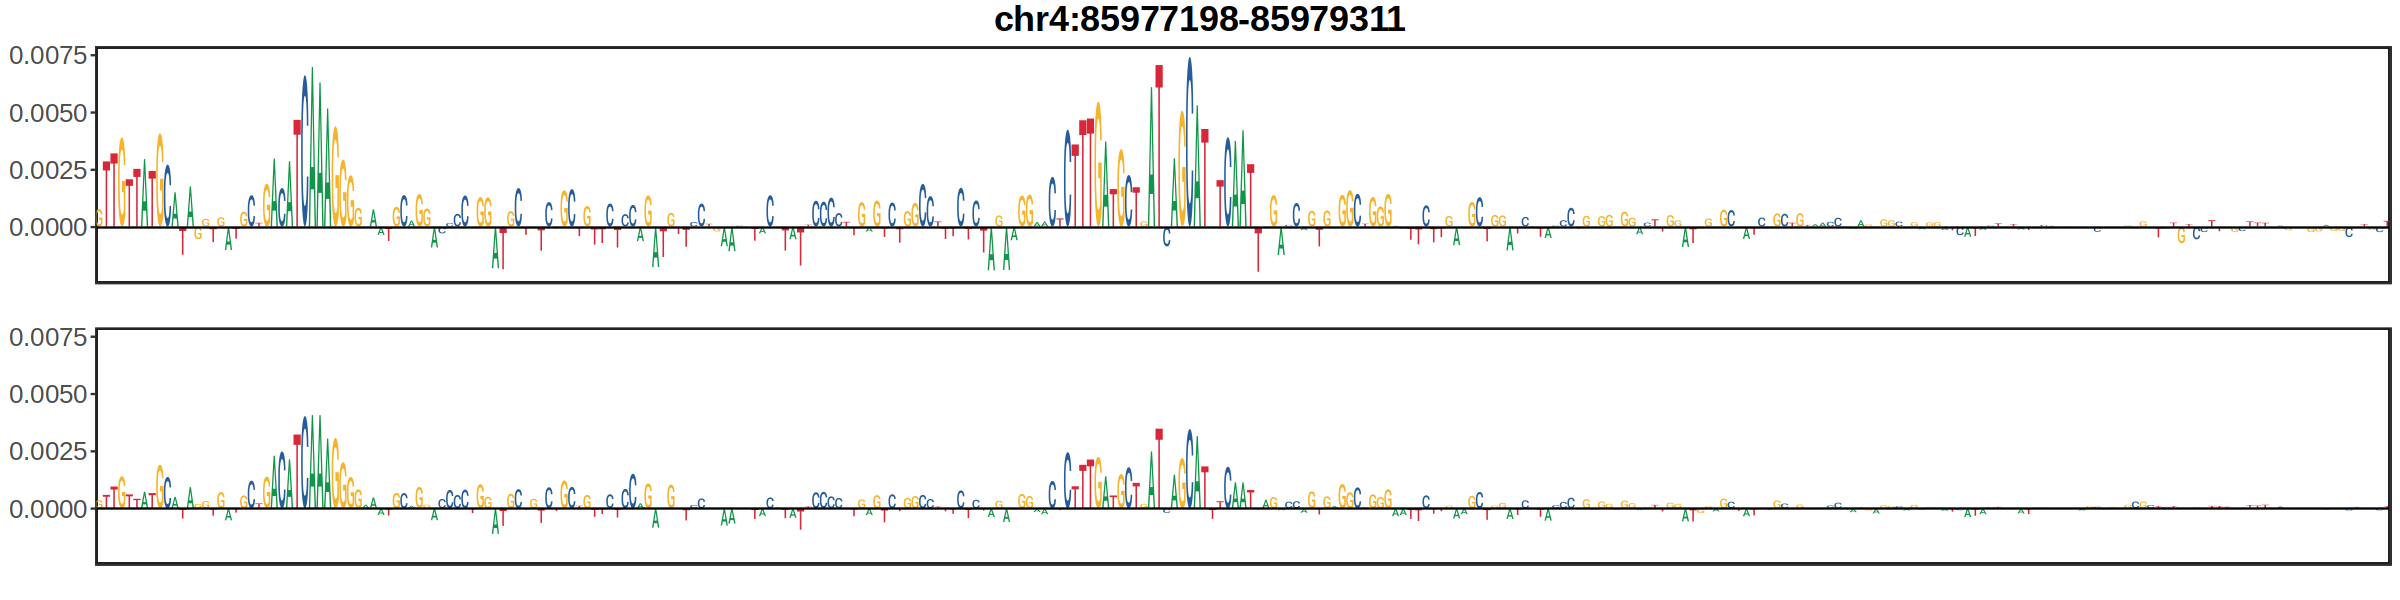

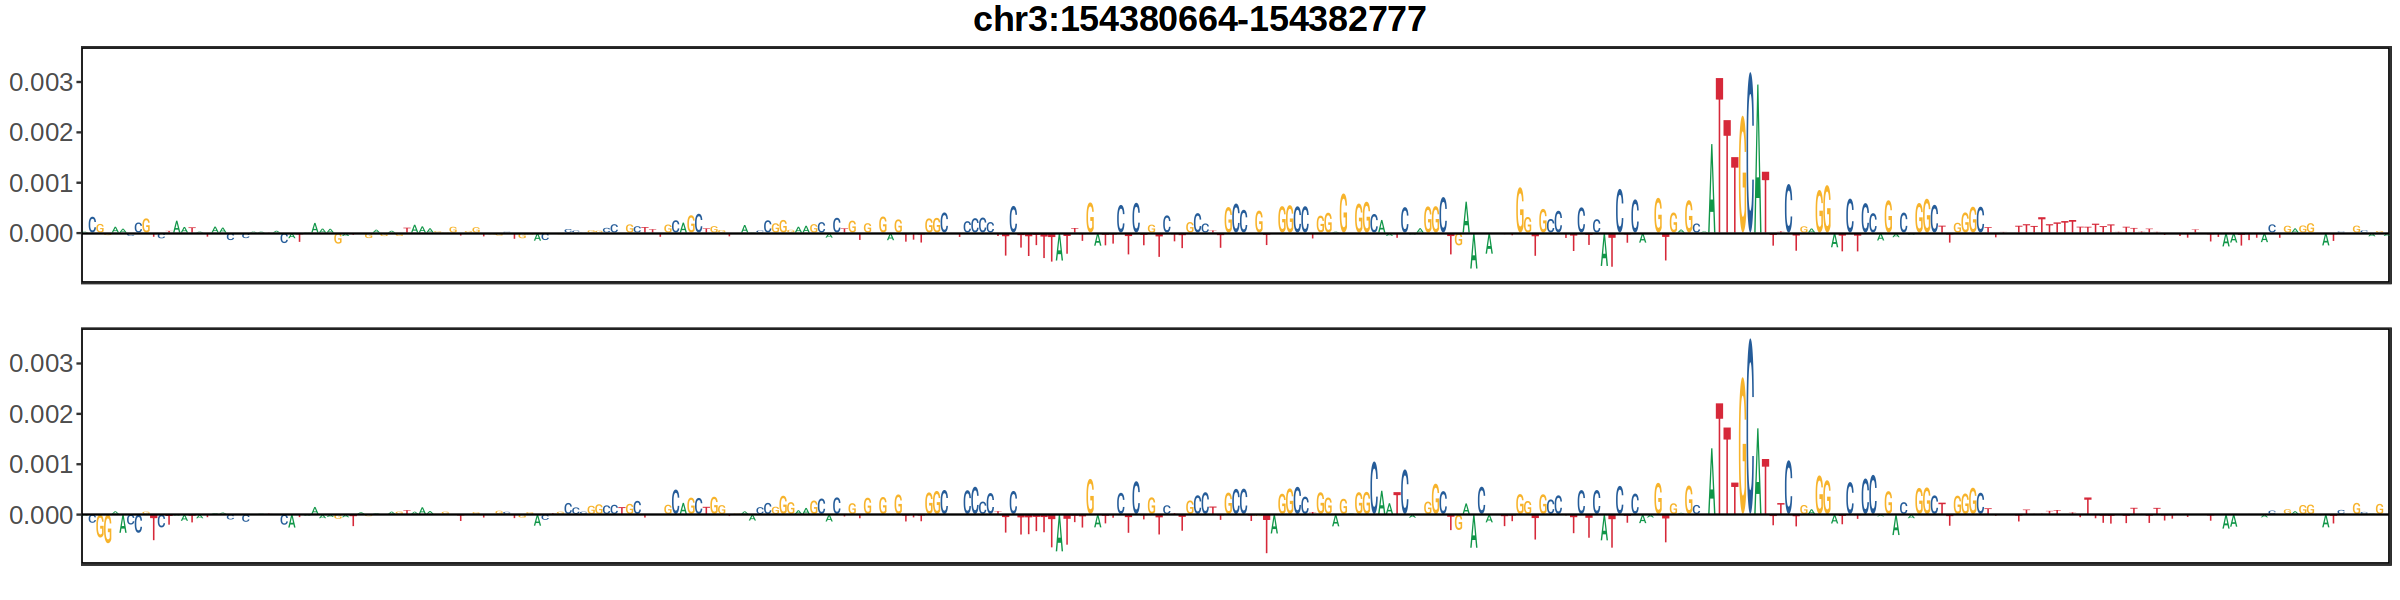

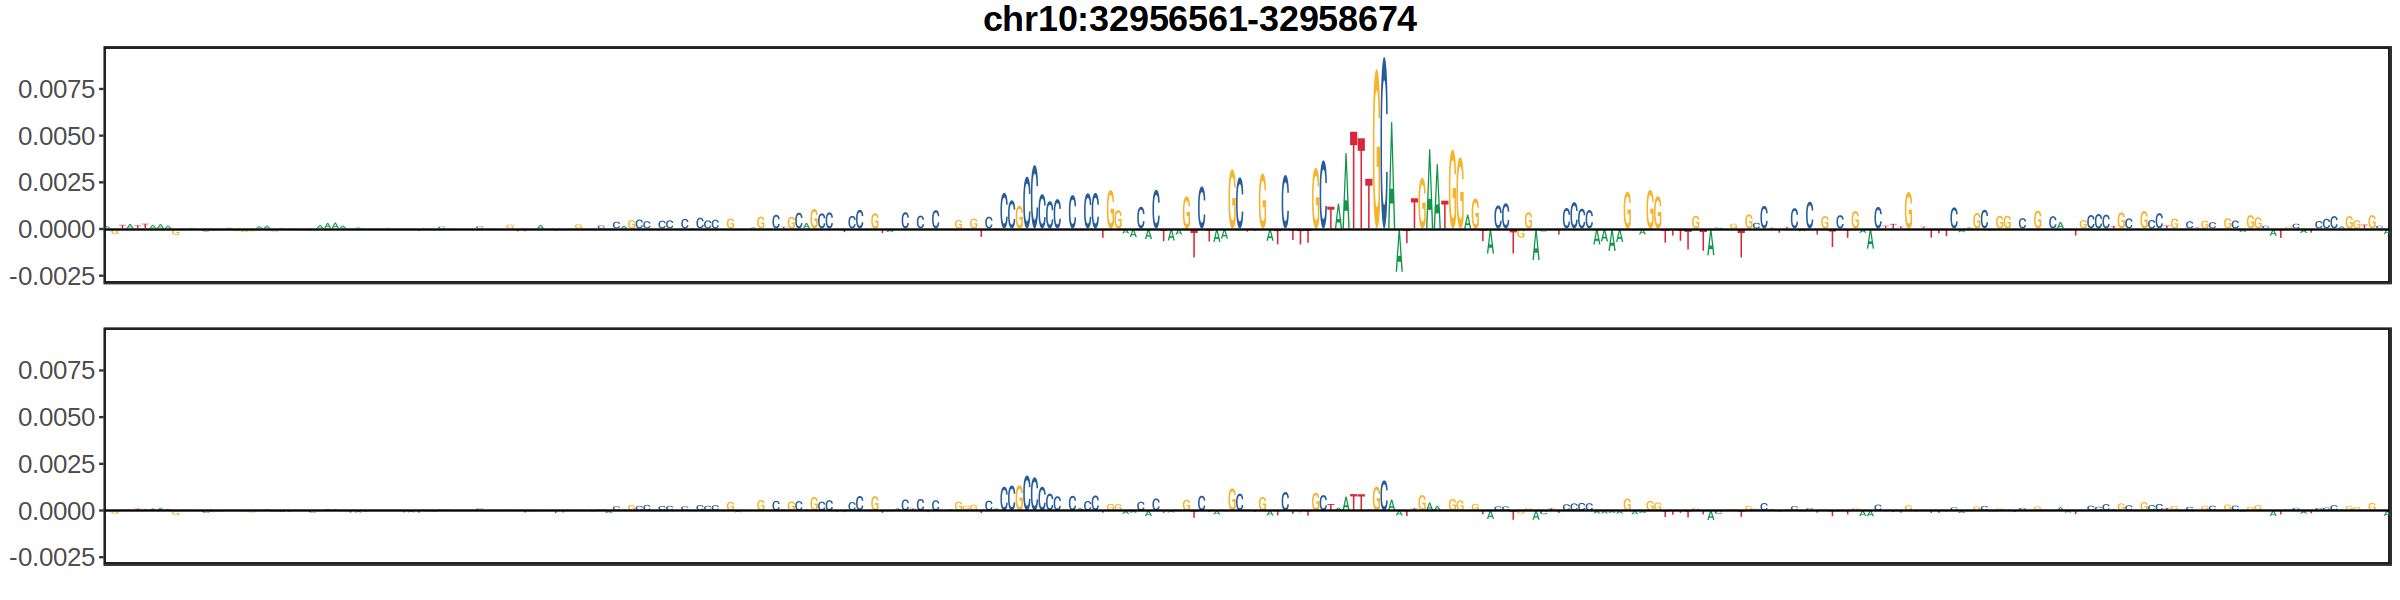

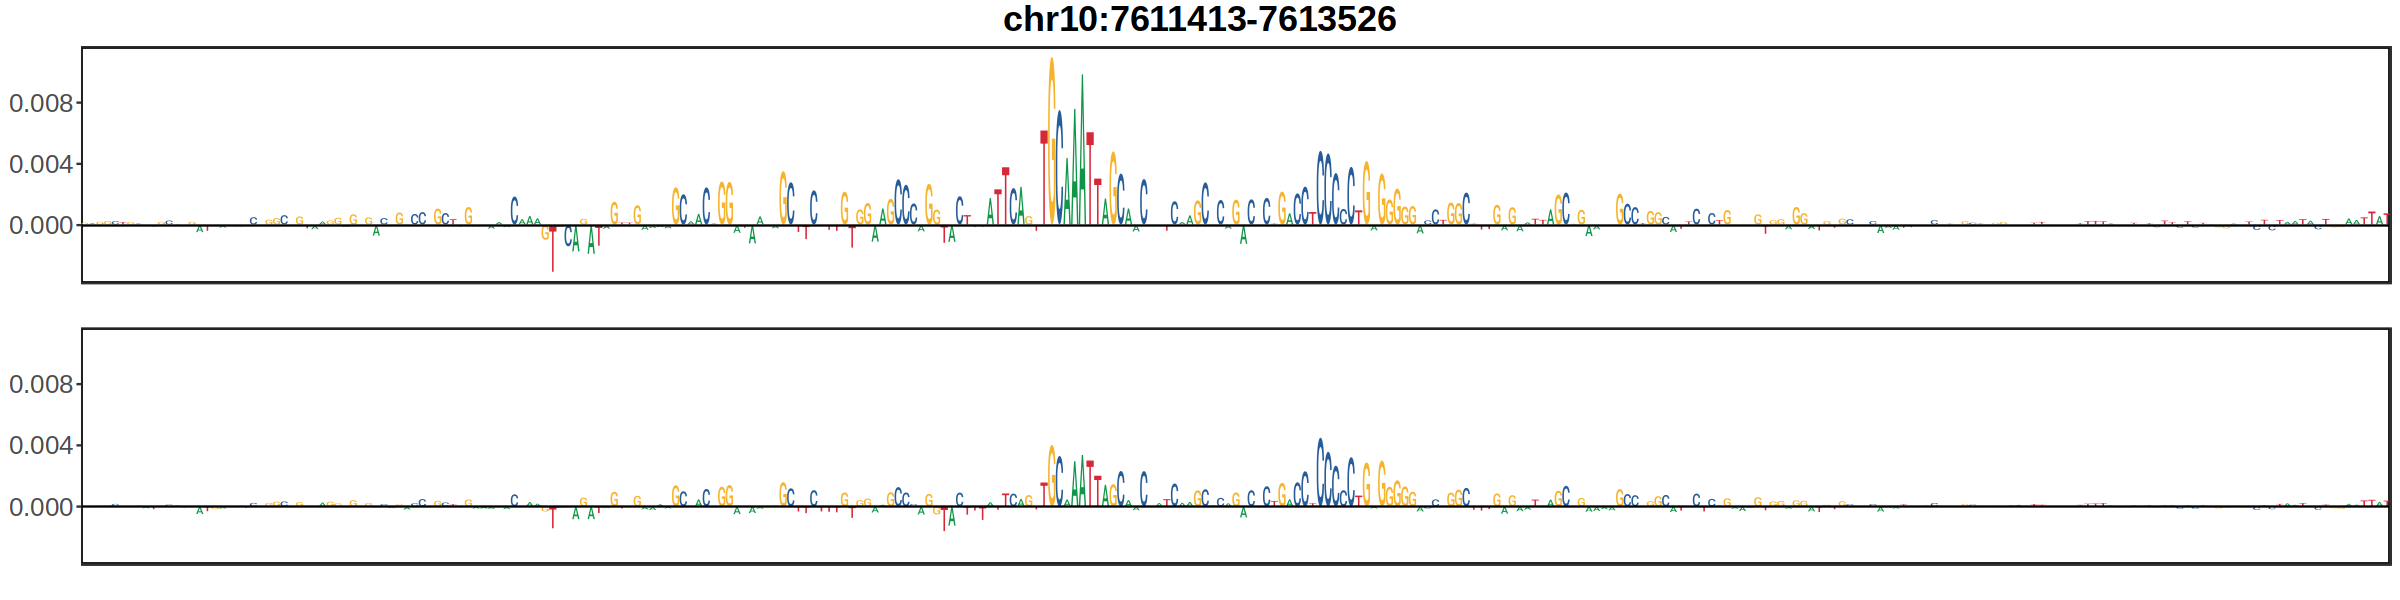

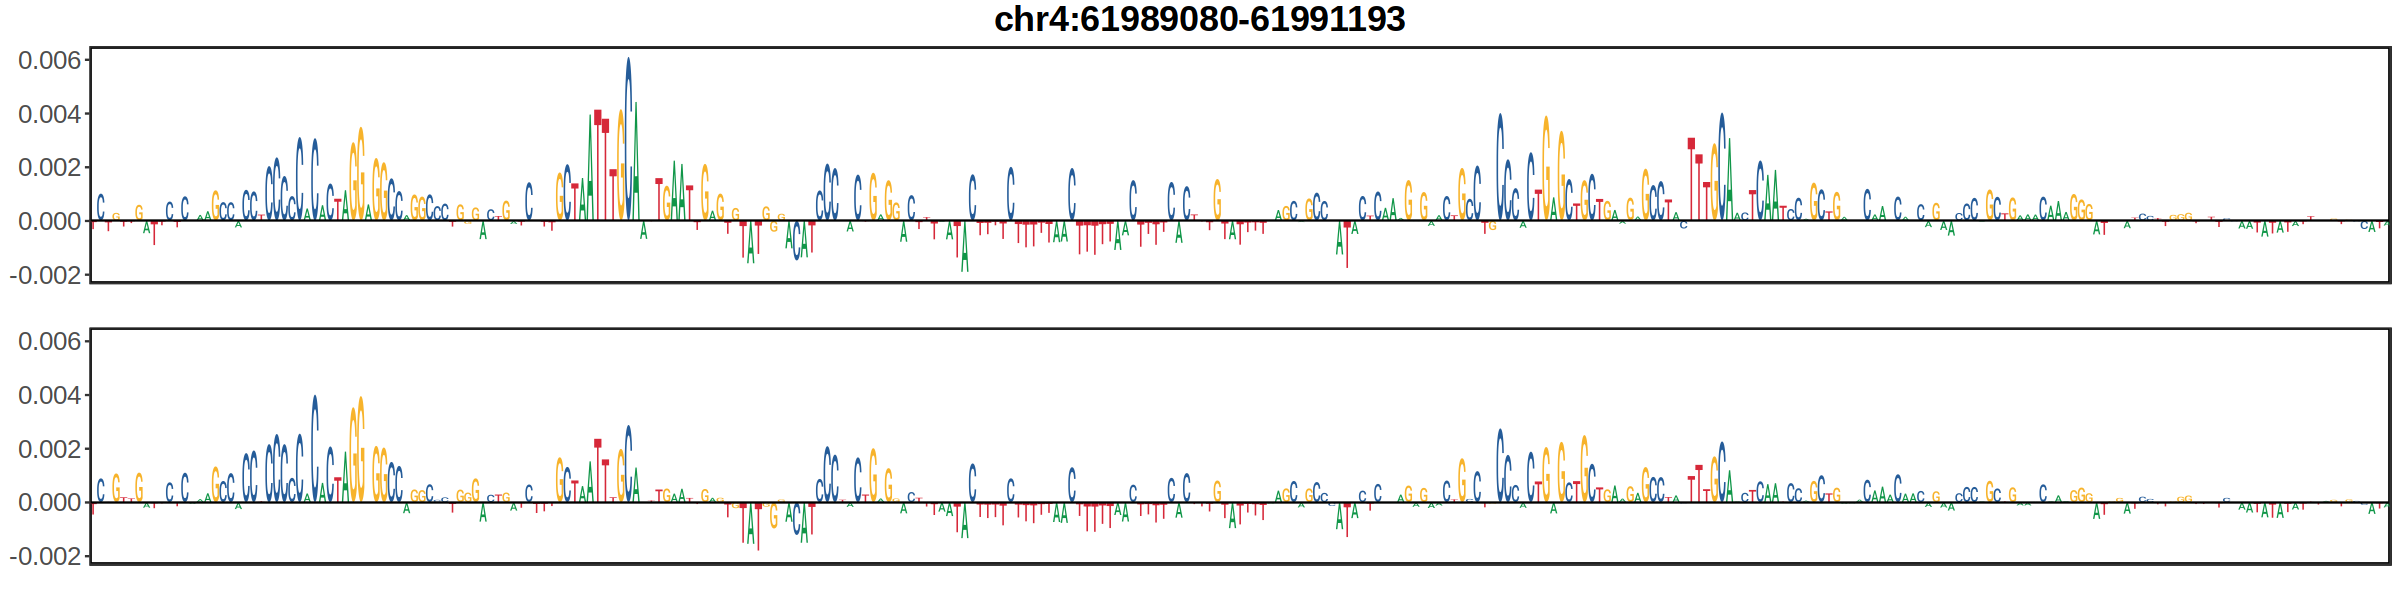

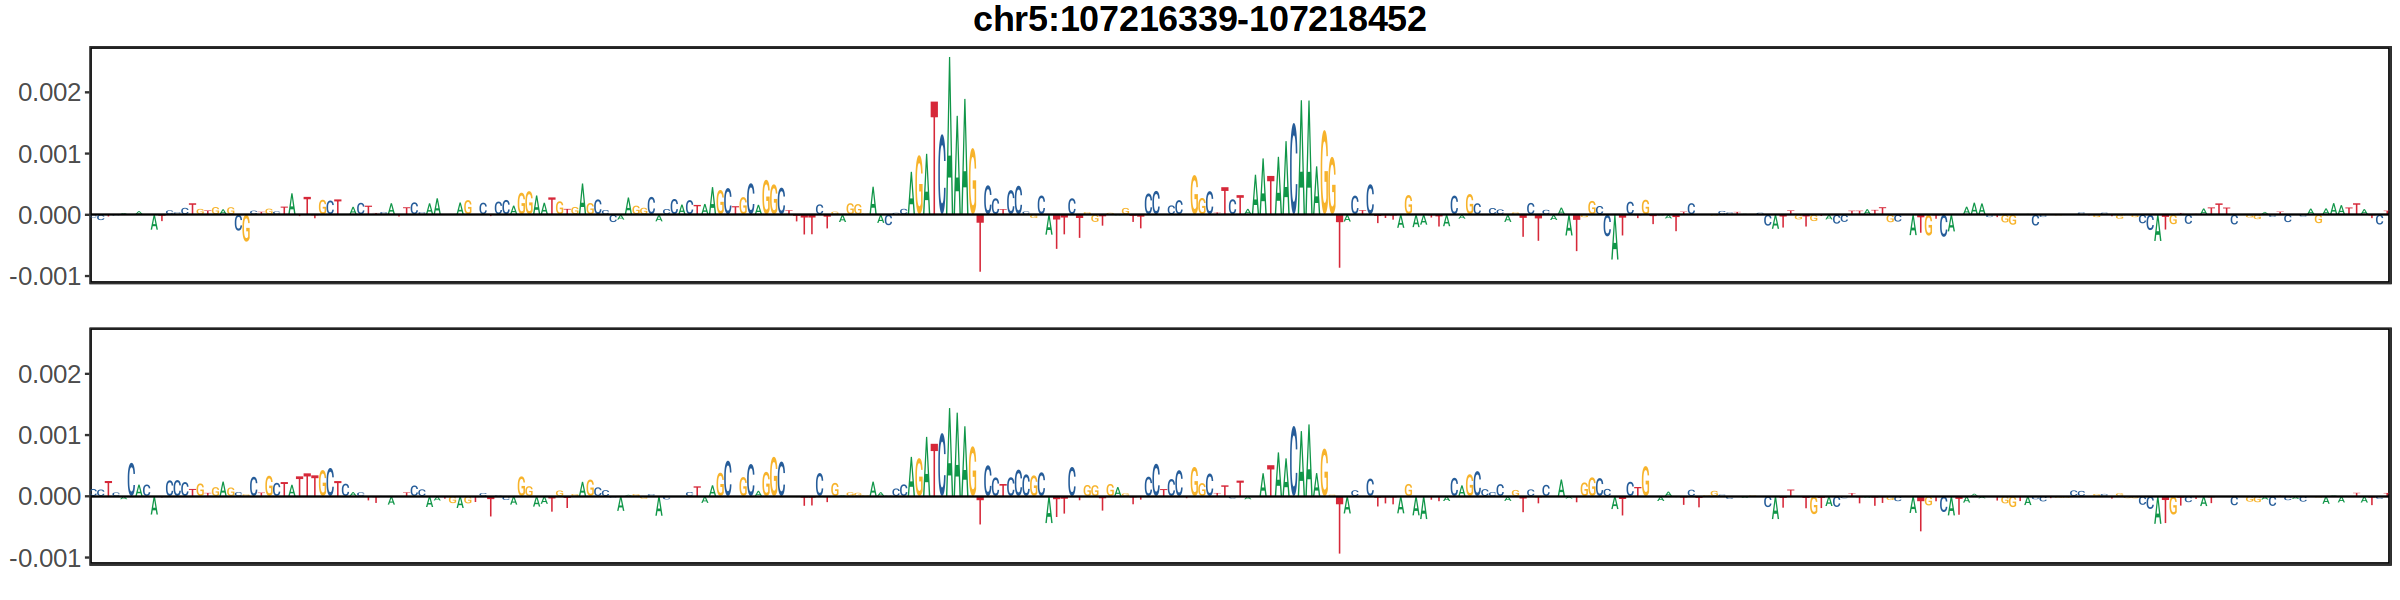

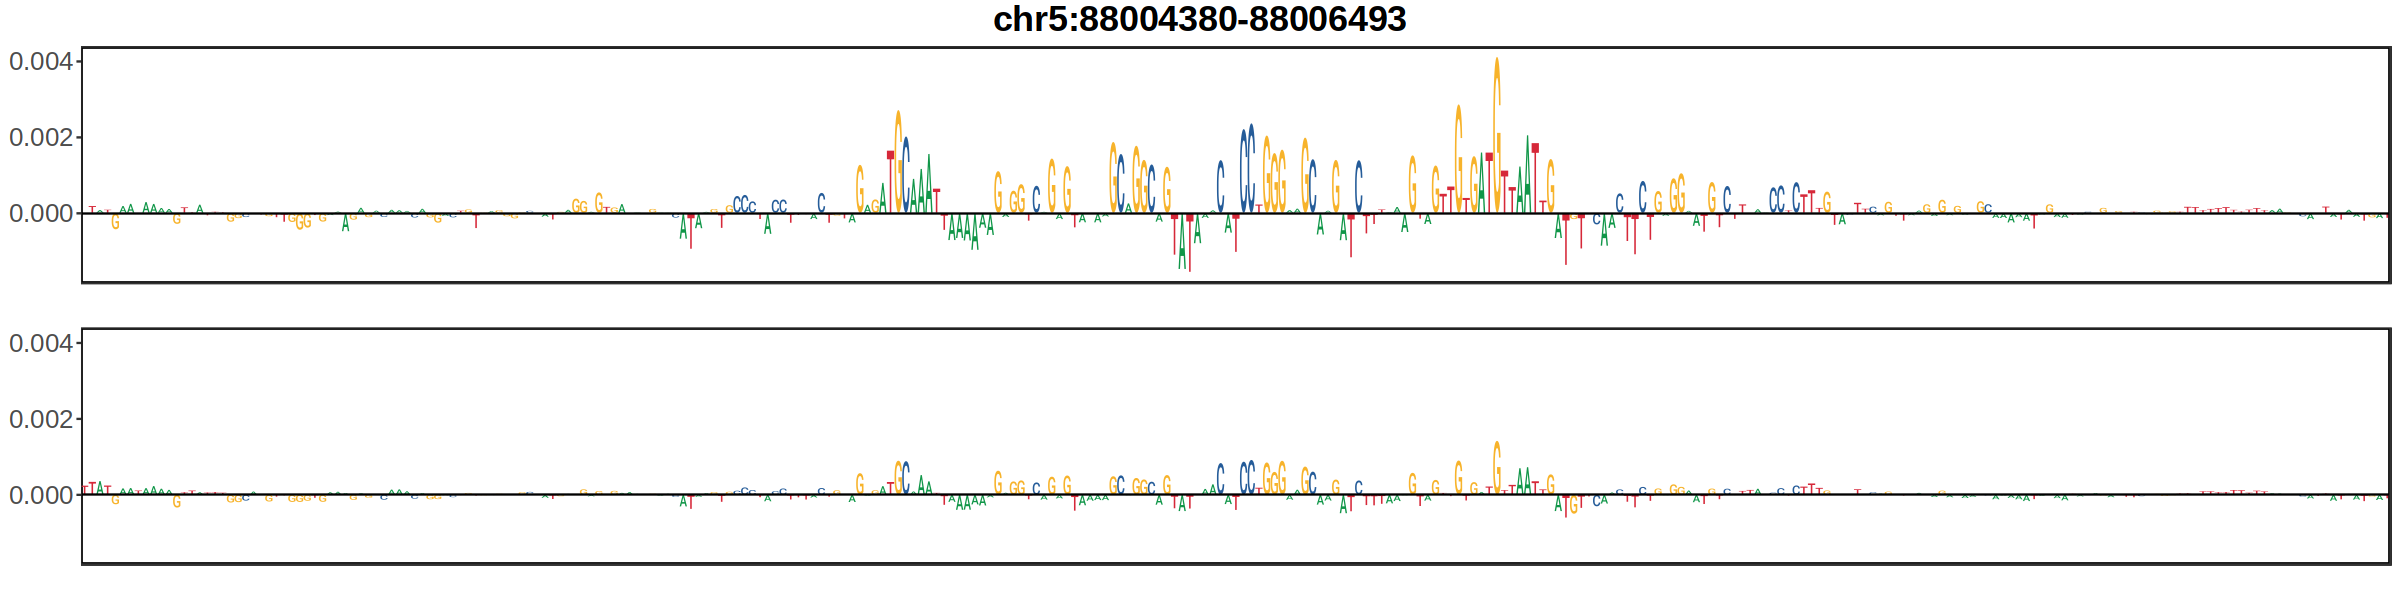

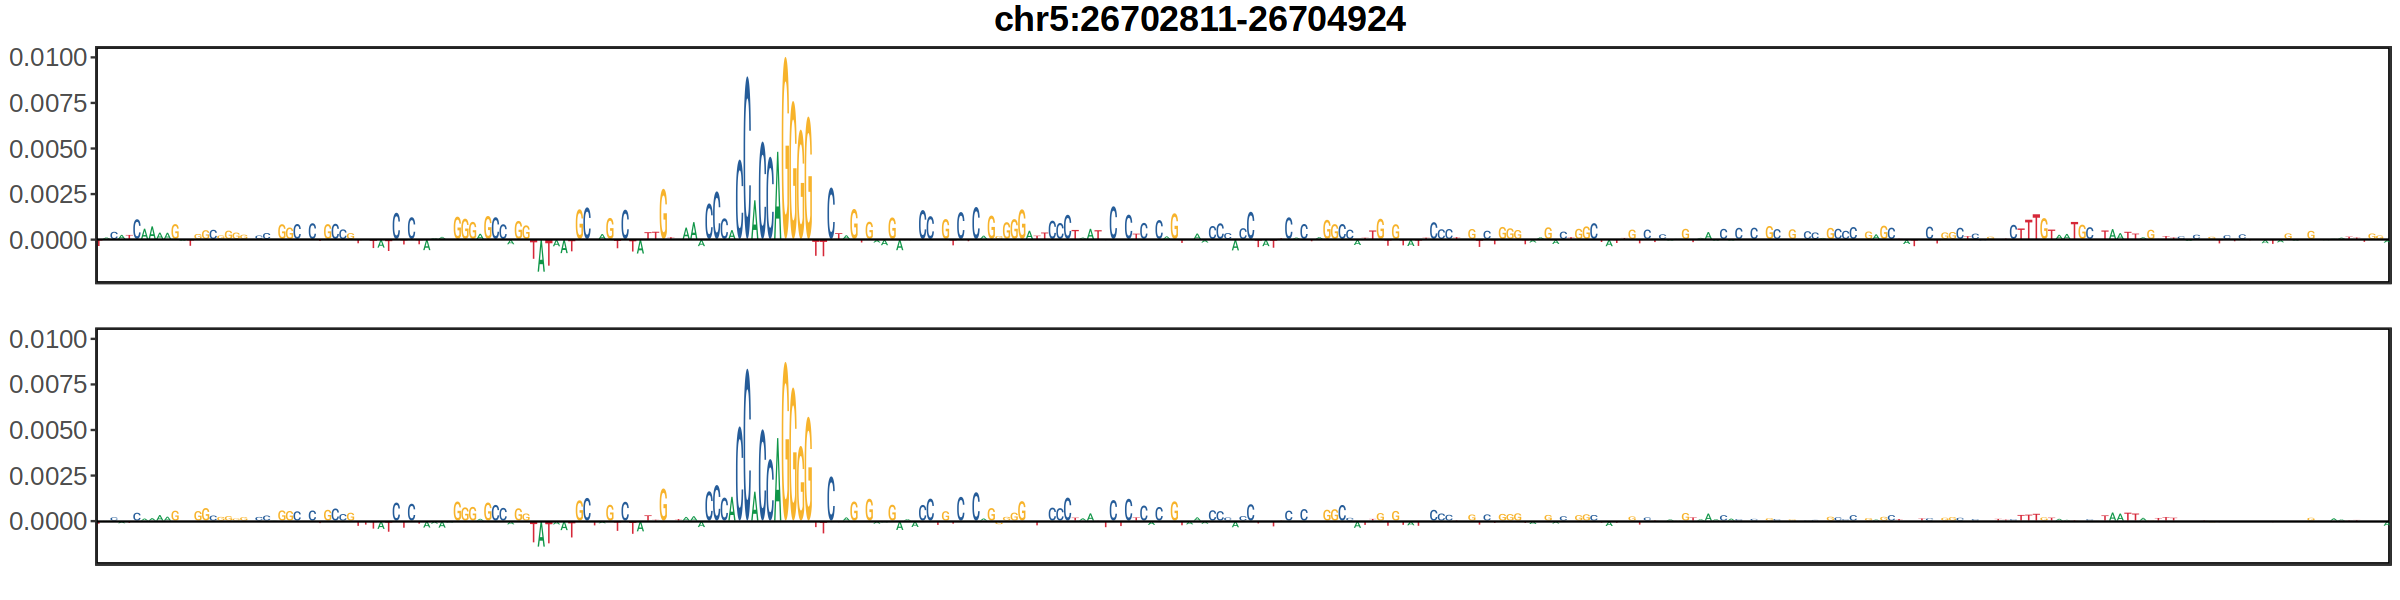

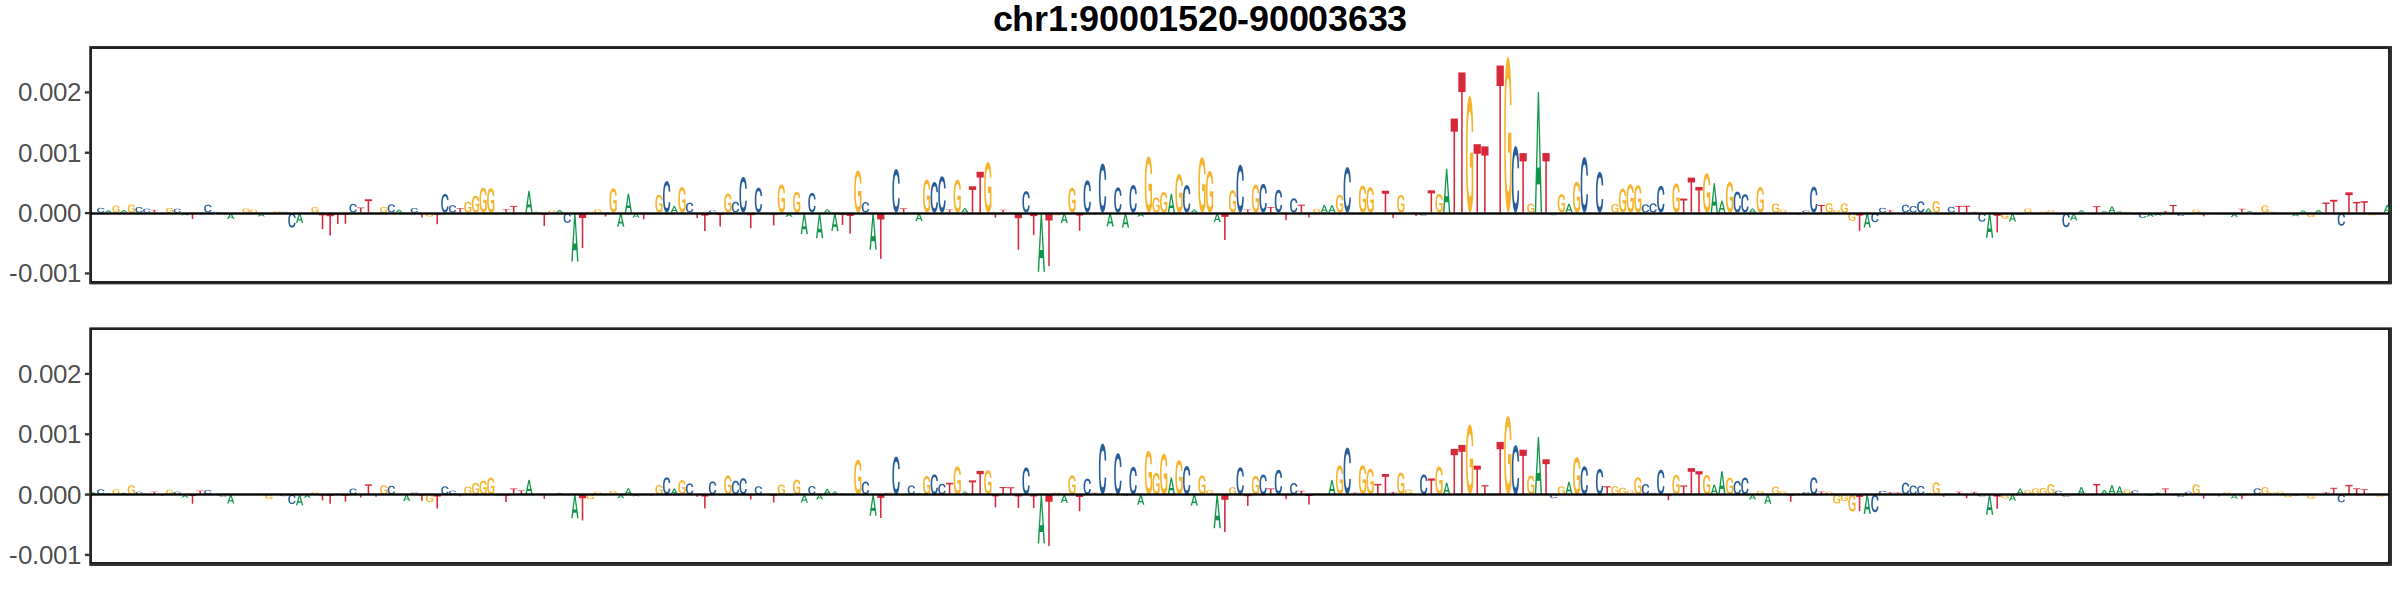

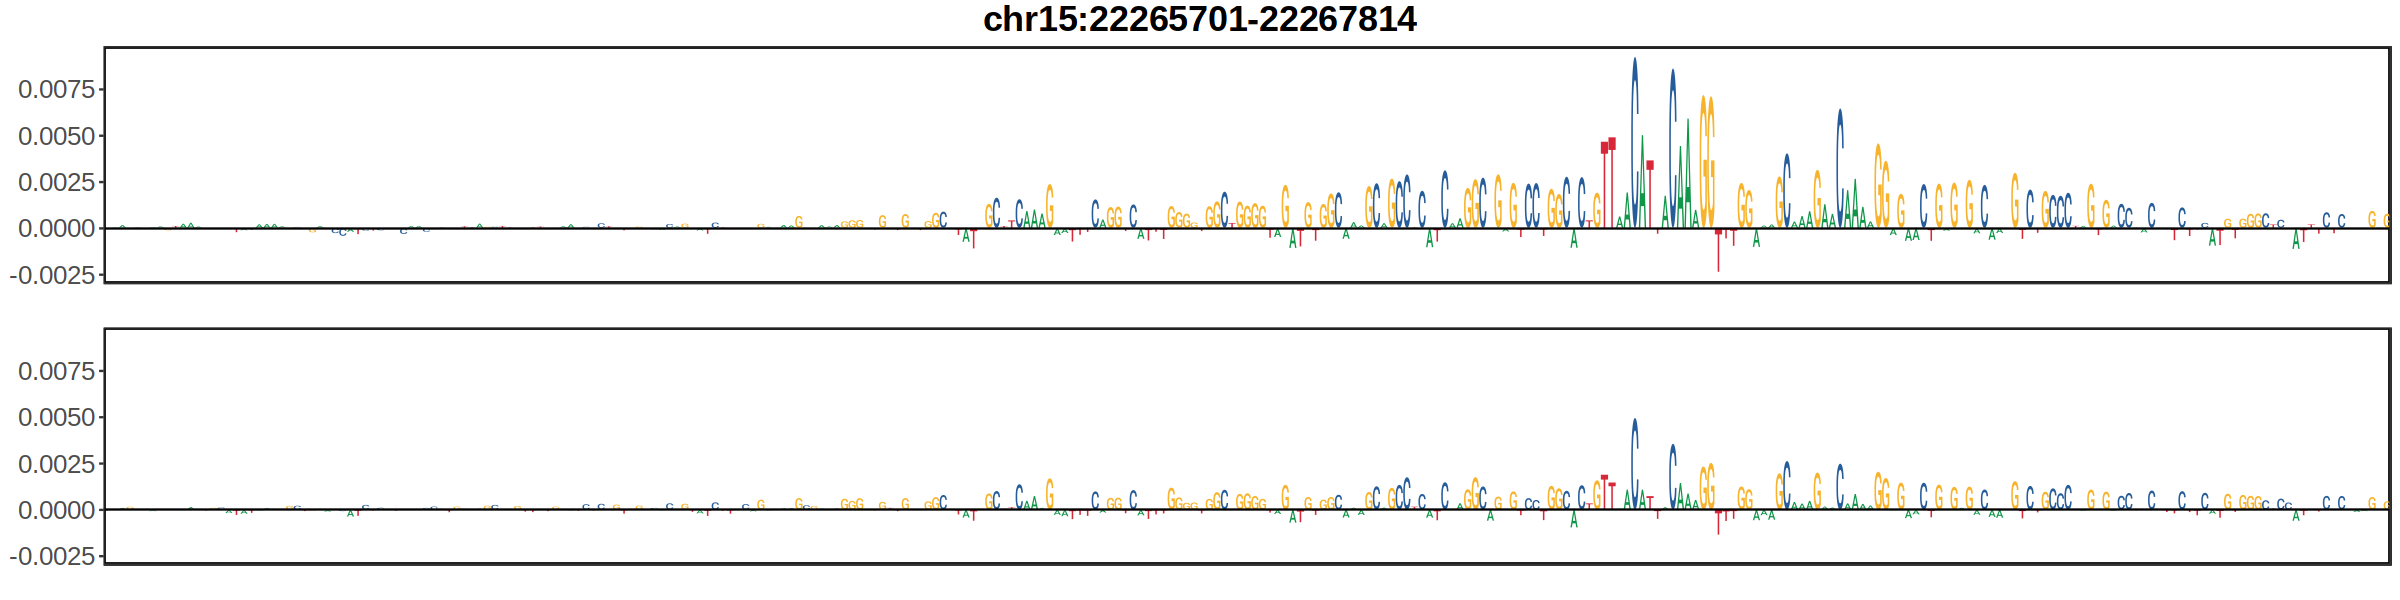

[[1]]

[[2]]

[[3]]
[1] "Error in dimnames(x) <- dn : \n  length of 'dimnames' [1] not equal to array extent\n"
attr(,"class")
[1] "try-error"
attr(,"condition")
<simpleError in dimnames(x) <- dn: length of 'dimnames' [1] not equal to array extent>

[[4]]

[[5]]

[[6]]

[[7]]

[[8]]

[[9]]

[[10]]

[[11]]

[[12]]

[[13]]

[[14]]

[[15]]

[[16]]

[[17]]

[[18]]

[[19]]

[[20]]

[[21]]

[[22]]
[1] "Error in dimnames(x) <- dn : \n  length of 'dimnames' [1] not equal to array extent\n"
attr(,"class")
[1] "try-error"
attr(,"condition")
<simpleError in dimnames(x) <- dn: length of 'dimnames' [1] not equal to array extent>

[[23]]

[[24]]

[[25]]

[[26]]

[[27]]

[[28]]

[[29]]

[[30]]

[[31]]

[[32]]

[[33]]

[[34]]

[[35]]

[[36]]

[[37]]

[[38]]

[[39]]

[[40]]


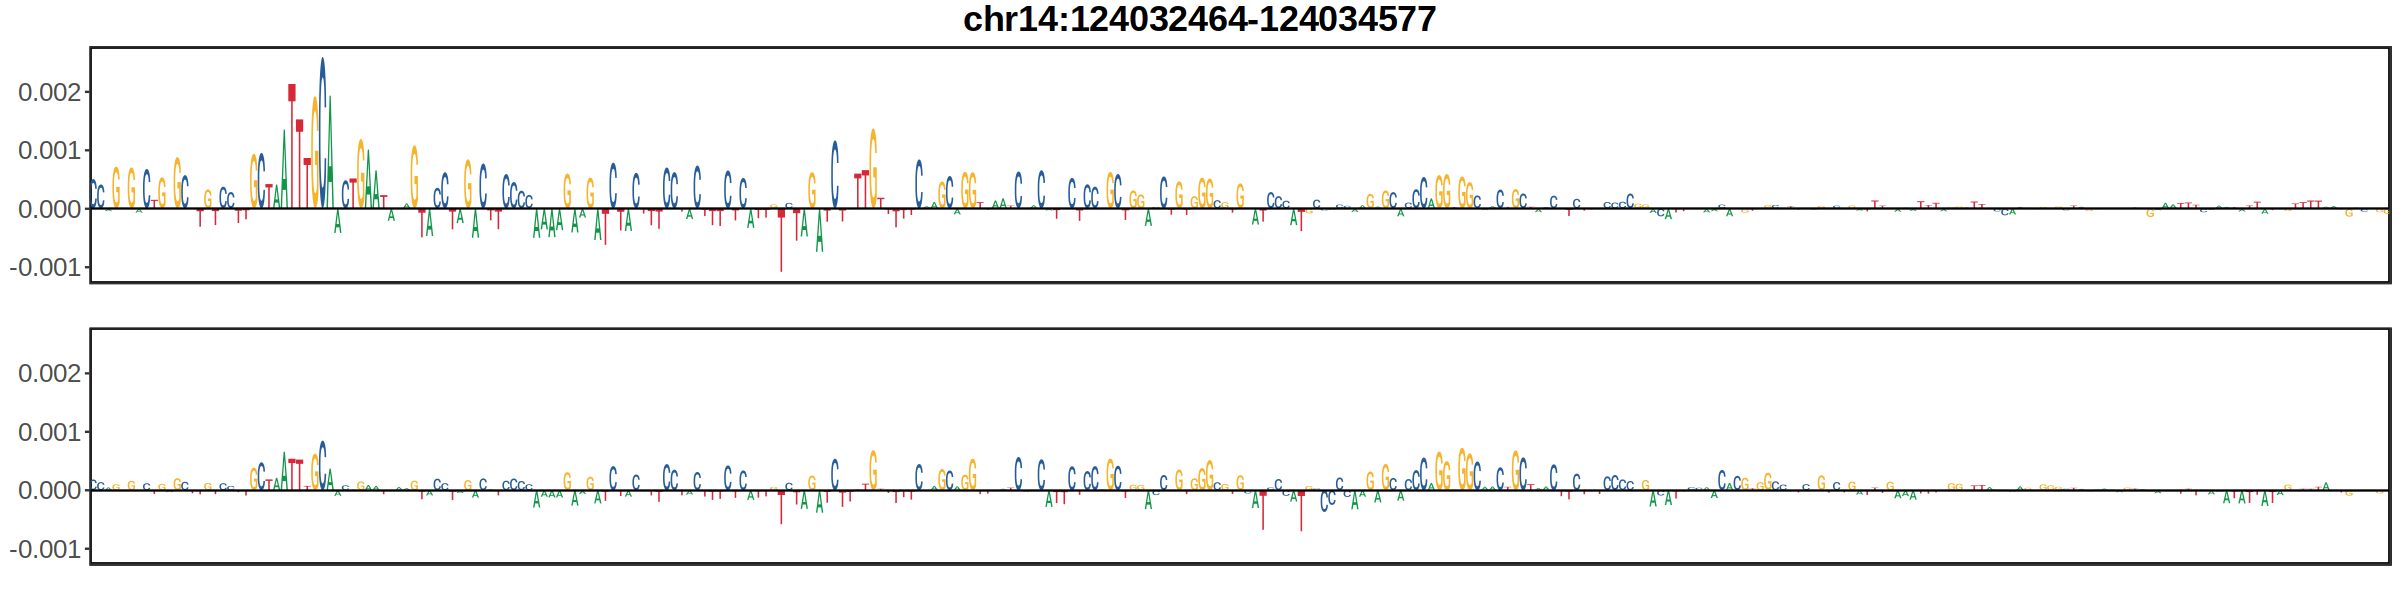

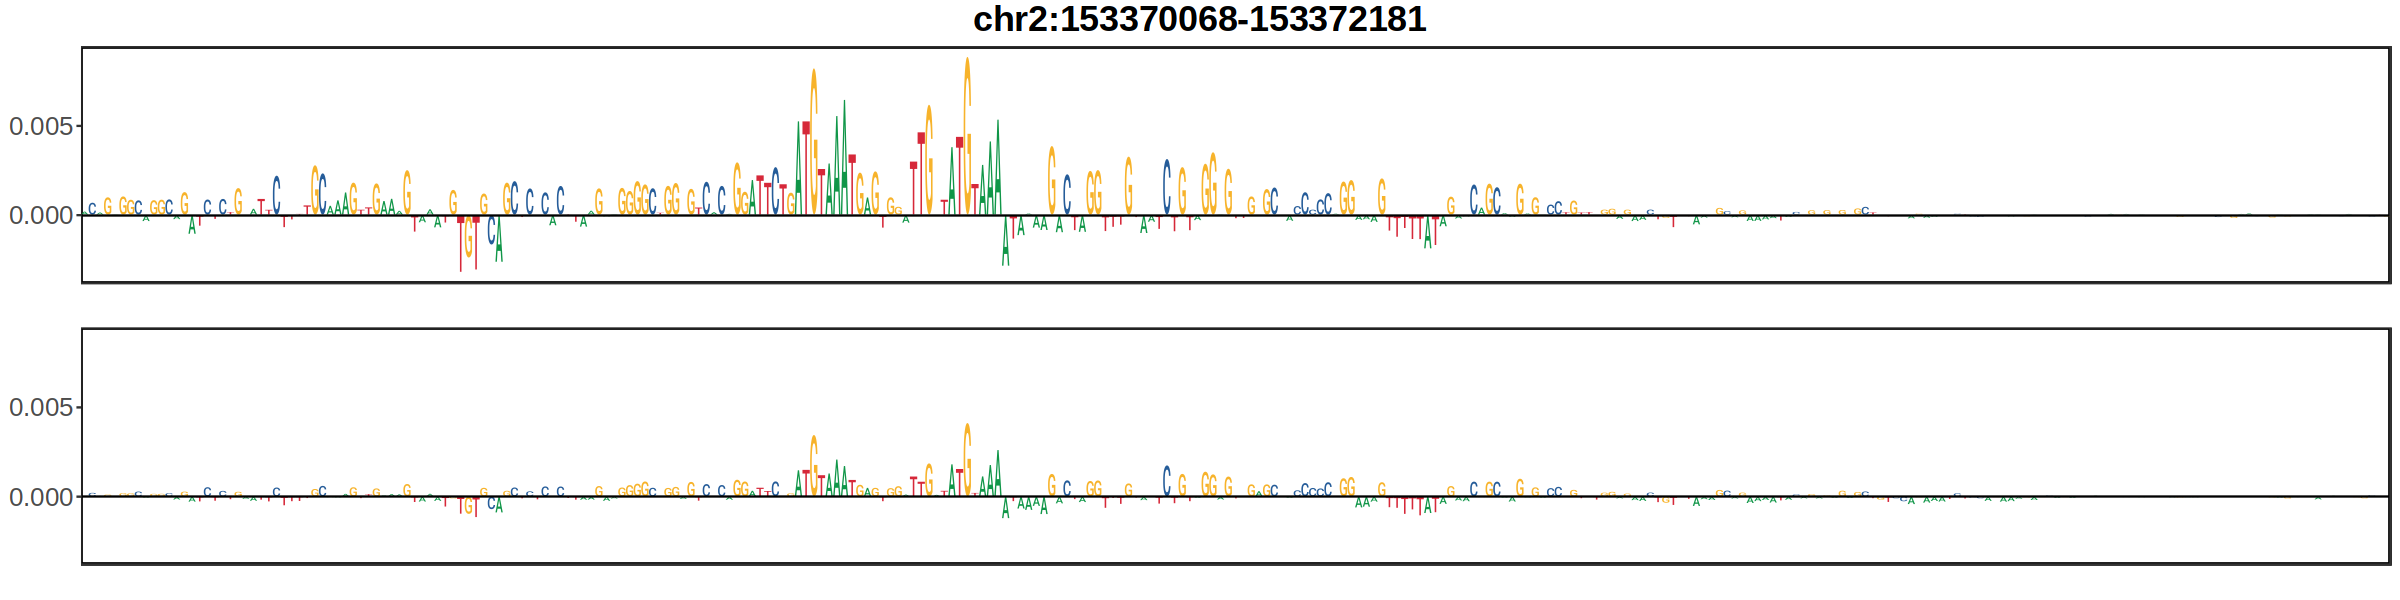

In [370]:
options(repr.plot.width = 20, repr.plot.height = 5)
mclapply(1:40, function(x){plot_peak(DARs[order(logFC)][x, peak], start = 350, end = 650)}, mc.cores = 40)

# individual folds

In [146]:
h5ls("/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/PS_EOi/fold0/predictions/contribs.profile_scores.h5")

,group,name,otype,dclass,dim
,<chr>,<chr>,<chr>,<chr>,<chr>
0,/,projected_shap,H5I_GROUP,,
1,/projected_shap,seq,H5I_DATASET,FLOAT,2114 x 4 x 206925
2,/,raw,H5I_GROUP,,
3,/raw,seq,H5I_DATASET,INTEGER,2114 x 4 x 206925
4,/,shap,H5I_GROUP,,
5,/shap,seq,H5I_DATASET,FLOAT,2114 x 4 x 206925


In [147]:
data_vector <- h5read("/rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/results/atac/chrombpnet/PS_EOi/fold0/predictions/contribs.profile_scores.h5", 
                      "/projected_shap/seq")
# Reshape into original dimensions: (1000, 4, 206925)
data_array <- array(data_vector, dim = c(2114, 4, 206925))

In [163]:
data_array <- array(data_vector, dim = c(2114, 4, 206925))

In [170]:
t(data_array[800:1200,,1])

0.0000000000,-0.0001257658,0.000000e+00,0.0000000000,0.0000000000,-1.40667e-05,0.0000000000,0.0000000000,0.000000e+00,0.0001827478,⋯,0.000000e+00,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.000000000,0.000000000,0.0000000000,0.0000000000
0.0000000000,0.0000000000,0.000000e+00,0.0000000000,0.0000000000,0.00000e+00,0.0000000000,-0.0004181862,0.000000e+00,0.0000000000,⋯,0.000000e+00,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.0000000000,0.000000000,0.000000000,0.0000000000,0.0000000000
-0.0002106428,0.0000000000,0.000000e+00,-0.0003604889,-0.0003993511,0.00000e+00,-0.0003454685,0.0000000000,0.000000e+00,0.0000000000,⋯,0.000000e+00,-0.0003056526,0.0000000000,-0.0008058548,0.0000000000,0.0000000000,0.000000000,0.000000000,0.0000000000,0.0000000000
0.0000000000,0.0000000000,5.245209e-06,0.0000000000,0.0000000000,0.00000e+00,0.0000000000,0.0000000000,8.702278e-05,0.0000000000,⋯,8.559227e-05,0.0000000000,0.0002042055,0.0000000000,0.0005350113,0.0007433891,0.001328468,0.000576973,0.0006422997,0.0004987717


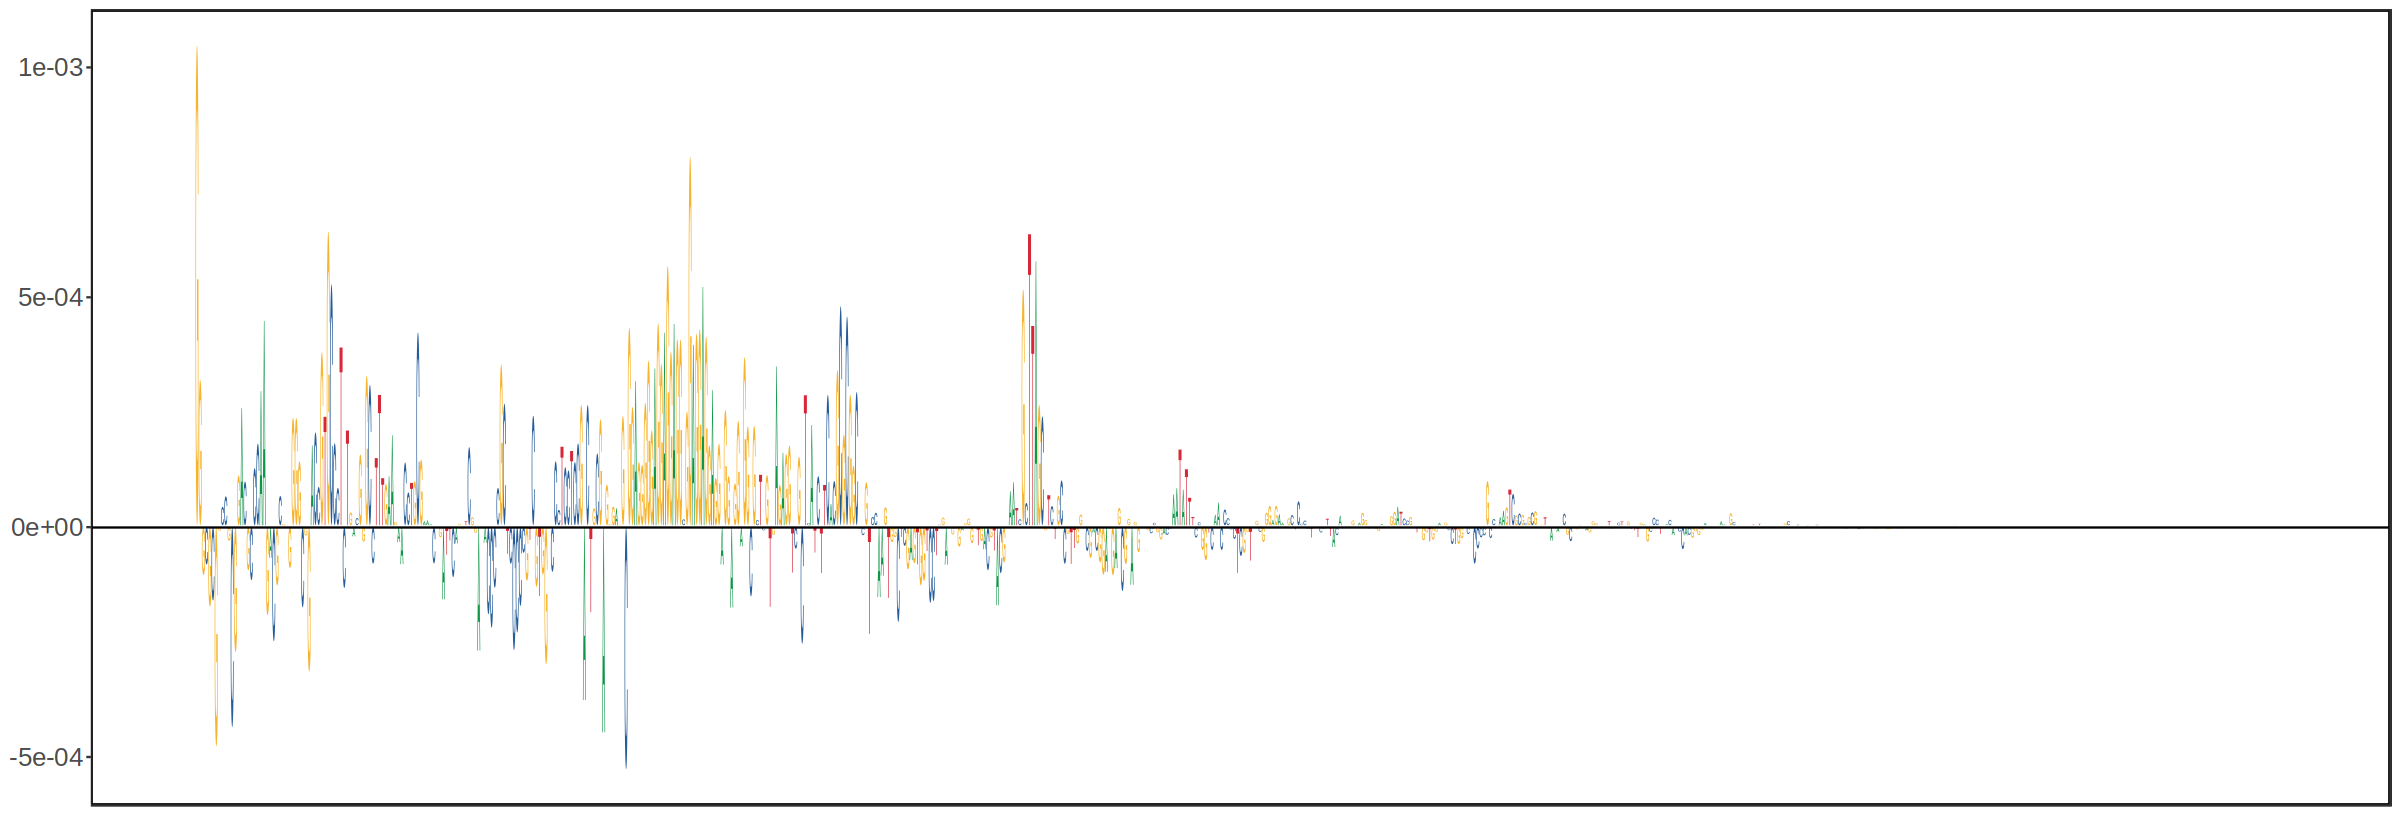

In [174]:
peak = peaks[peak == 'chr9:118478159-118480272', I]
tmp = t(data_array[1052-400:1052+100,,peak])
rownames(tmp) = c('A', 'C', 'G', 'T')

options(repr.plot.width = 20, repr.plot.height = 7)
ggseqlogo(tmp, method='custom', seq_type='dna') + ylab('my custom height') + 
            geom_hline(yintercept = 0) +
                theme_bw() + 
                theme(panel.grid = element_blank(), 
                      panel.background = element_rect(color = 'black', fill = NA, linewidth = 1),
                      axis.text.y = element_text(size = 15),
                     axis.title.y = element_blank(),
                     axis.text.x = element_blank(),
                     axis.ticks.x = element_blank())